In [1]:
%matplotlib widget

Per ogni sorgente modificare:
- z e controllare che lambda lines corrisponda
- sigma e seeing
- n_component
- regione estrazione cielo
- taglio immagine in y
- funzioni di plot e model_convolved
- bounds_HA (ampiezza dell'intervallo sulle x è +- la metà del seeing) e bounds
- salvataggio fit

In [2]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [3]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


In [4]:
image_cut = image[56:156, 0:1890]
image_error_cut = image_error[56:156, 0:1890]

Text(0.5, 0, 'wavelength')

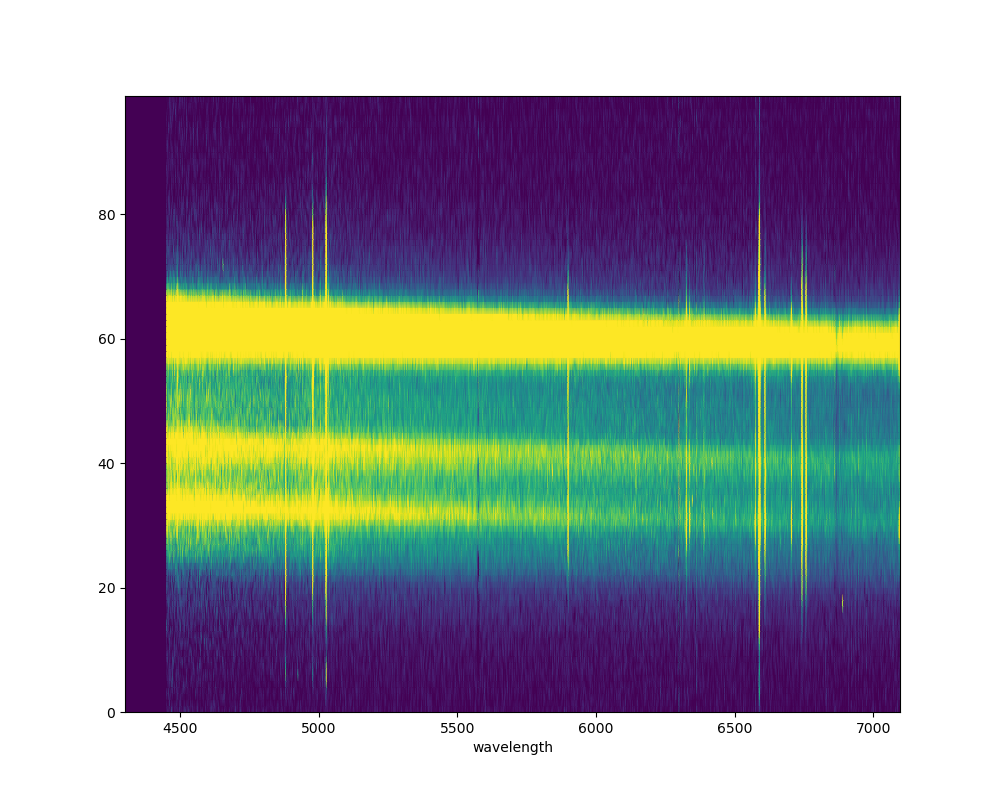

In [5]:
wv = np.arange(4300.74, 4300.74+1890*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10,8))
plt.pcolormesh(x_grid, y_grid, image_cut, shading='gouraud', vmin=np.percentile(image_cut, 15), vmax=np.percentile(image_cut, 90))
plt.xlabel('wavelength')

## Redshift or the lines in air

In [6]:
z = 0.00442
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

seeing = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/PSF/Real_seeing_Mrk1263.txt")
sigmas = seeing / 2.35
print(sigmas)

[1.00950914 1.1229436  1.00774775 0.9959783  1.11963204 1.01319149]


## Sky lines

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     359   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        40   (2094, 964)   float32   


Text(0.5, 0, 'wavelength')

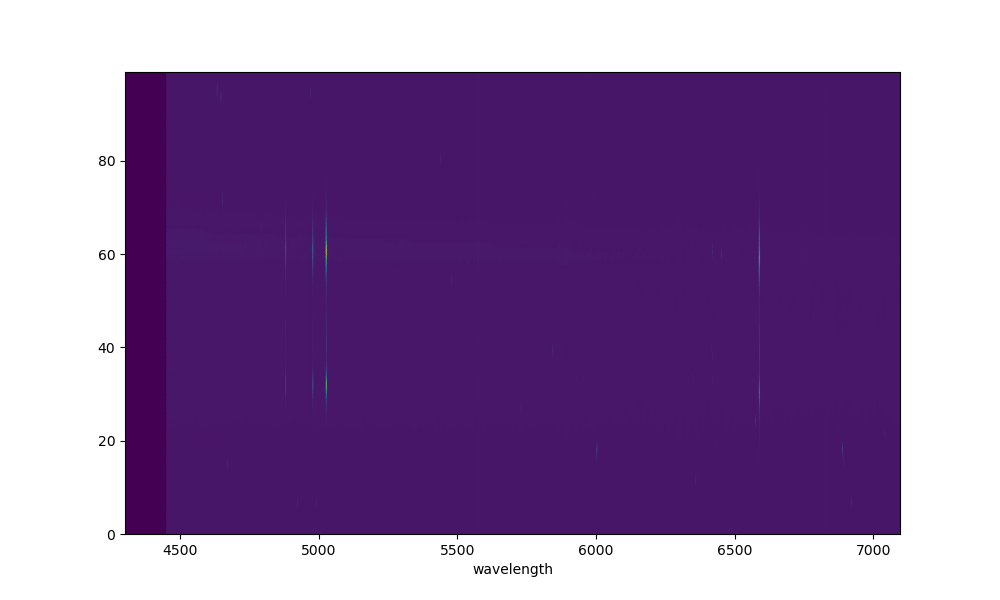

In [7]:
hdul2 = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Mrk-1263_MAPPED_FLUX_ALL_SCI_LSS_U1.fits")
hdul2.info()
image2 = hdul2[0].data
image_cut2 = image2[56:156, 0:1890]

x_grid, y_grid = np.meshgrid(wv, y)
plt.figure(figsize=(10, 6))
plt.pcolormesh(x_grid, y_grid, image_cut2, shading='gouraud')#, vmin = np.percentile(image_cut, 20), vmax = 0.16)
plt.xlabel('wavelength')

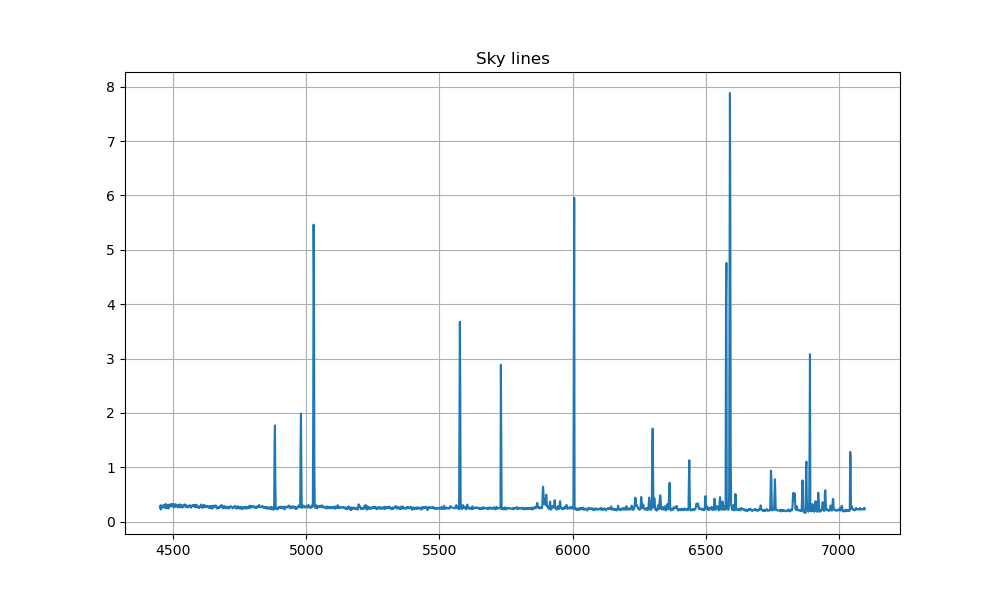

In [8]:
mask_sky = (y > 18)*(y < 28)
mask_wv = wv > 4451
image_sky = image_cut2[np.ix_(mask_sky, mask_wv)]
radial_profile_sky = np.sum(image_sky, axis = 0)
plt.figure(figsize=(10, 6))
plt.plot(wv[mask_wv], radial_profile_sky)

plt.grid()
plt.title(r'Sky lines')

plt.savefig('Sky_lines')

## H$\alpha$

Text(0.5, 1.0, 'H$\\alpha$')

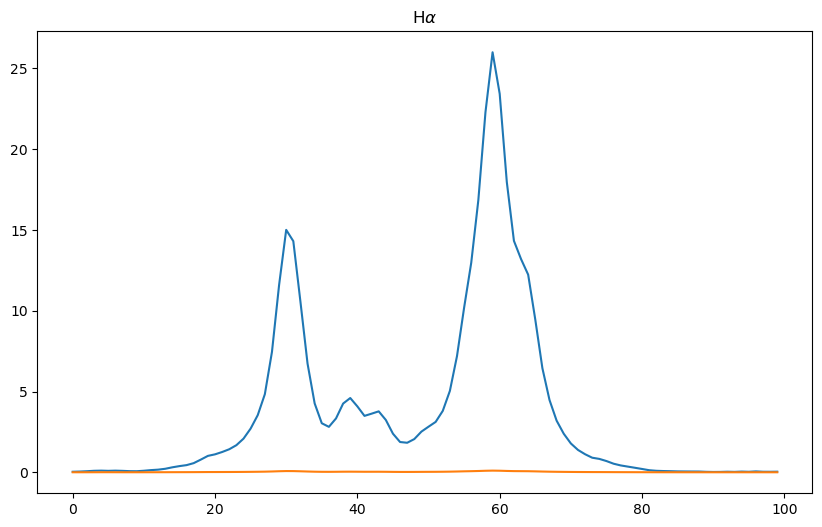

In [8]:
mask_HA = (wv > l_HA-8)*(wv < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

sky_err = np.loadtxt("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_1263/FORS2.2022-01-06T07_26_01.965/Propag_errori/Sky_errors.txt")
real_errors_HA = np.sqrt(radial_profile_error_HA**2+(sky_err[2])**2+(0.04*radial_profile_HA)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [28]:
n_component = 5

def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, I_e, r_e, n, x_0):
    """ Profilo Sérsic 1D centrato in x_0 """
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))

def model_convolved(x, sigma, *params):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, *params[0:4]) +
        sersic_1d(x_hr, *params[4:8]) +
        sersic_1d(x_hr, *params[8:12]) +
        sersic_1d(x_hr, *params[12:16])+
        sersic_1d(x_hr, *params[16:20]) #+
        #sersic_1d(x_hr, *params[20:24])
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def chi_squared(params, x, y_obs, sigma):
    y_model = model_convolved(x, sigma, *params)
    return np.sum((y_obs - y_model)**2)

def sersic_1d_convolved(x, I_e, r_e, n, x_0, sigma):
    """ Sérsic convoluto con PSF gaussiana """
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = sersic_1d(x_hr, I_e, r_e, n, x_0)
    psf = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 43)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    ax[0].set_ylim(0, 43)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

bounds_HA =[
    (0, 1),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 50),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (25, 35),   # x_0: posizione da 0 a 100

    (0, 1),
    (0, 50),
    (0.1, 10),
    (35, 40),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (40, 45),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (55, 63),

    (0, 1),
    (0, 50),
    (0.1, 10),
    (60, 65)
]

def save_params(params_curve, covariance, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    I_e_err = np.zeros(n_component)
    r_e_err = np.zeros(n_component)
    n_err = np.zeros(n_component)
    x_0_err = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        I_e_err[i] = np.sqrt(np.diag(covariance)[i*4])
        r_e_err[i] = np.sqrt(np.diag(covariance)[(i*4)+1])
        n_err[i] = np.sqrt(np.diag(covariance)[(i*4)+2])
        x_0_err[i] = np.sqrt(np.diag(covariance)[(i*4)+3])
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    print(np.sqrt(np.diag(covariance)))
    chi2 = np.sum((((radial_profile - model_convolved(x_axes, sigma, *params_curve)) / radial_profile_error)**2))
    dof = len(radial_profile) - len(params_curve)
    chi2_reduced = chi2 / dof
    print(chi2_reduced)

    param_dict = {}
    error_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
        error_dict[component_name] = [I_e_err[i], r_e_err[i], n_err[i], x_0_err[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    df_errors = pd.DataFrame(data=error_dict, index=['I_e error', 'r_e error', 'n error', 'x_0 error'])
    
    # Salva file CSV
    if line_name:
        param_filename = f"{line_name}_{output_prefix}.csv"
        error_filename = f"{line_name}_{output_prefix}_errors.csv"
    
    df_params.to_csv(param_filename, float_format='%.4f')
    df_errors.to_csv(error_filename, float_format='%.4f')
    return chi2_reduced, dof, chi2

def save_params_diff(params_curve, radial_profile, radial_profile_error, sigma, x_axes, n_component, line_name="", output_prefix="fit"):
    I_e = np.zeros(n_component)
    r_e = np.zeros(n_component)
    n = np.zeros(n_component)
    x_0 = np.zeros(n_component)

    for i in range(n_component):
        I_e[i], r_e[i], n[i], x_0[i] = params_curve[i*4:(i+1)*4]
        print(f"Sérsic {i+1}: I_e={I_e[i]:.4f}, r_e={r_e[i]:.4f}, n={n[i]:.4f}, x_0={x_0[i]:.4f}")

    param_dict = {}
    
    for i in range(n_component):
        component_name = f'Component {i+1}'
        param_dict[component_name] = [I_e[i], r_e[i], n[i], x_0[i]]
    
    # Crea DataFrame
    df_params = pd.DataFrame(data=param_dict, index=['I_e', 'r_e', 'n', 'x_0'])
    
    output_dir = "Diff_params"
    os.makedirs(output_dir, exist_ok=True)

    # Salva file CSV nella cartella Diff_params
    if line_name:
        param_filename = os.path.join(output_dir, f"{line_name}_{output_prefix}_diff.csv")
    
    df_params.to_csv(param_filename, float_format='%.4f')

In [29]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HA, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2196.640886836109
differential_evolution step 2: f(x)= 2056.4526646306695
differential_evolution step 3: f(x)= 1013.3194261519674
differential_evolution step 4: f(x)= 1013.3194261519674
differential_evolution step 5: f(x)= 1013.3194261519674
differential_evolution step 6: f(x)= 531.0176314078003
differential_evolution step 7: f(x)= 458.2797970447961
differential_evolution step 8: f(x)= 458.2797970447961
differential_evolution step 9: f(x)= 458.2797970447961
differential_evolution step 10: f(x)= 458.2797970447961
differential_evolution step 11: f(x)= 458.2797970447961
differential_evolution step 12: f(x)= 458.2797970447961
differential_evolution step 13: f(x)= 458.2797970447961
differential_evolution step 14: f(x)= 441.5797519351836
differential_evolution step 15: f(x)= 441.5797519351836
differential_evolution step 16: f(x)= 441.5797519351836
differential_evolution step 17: f(x)= 441.5797519351836
differential_evolution step 18: f(x)= 441.57975193518

Sérsic 1: I_e=1.0000, r_e=9.0449, n=1.9725, x_0=30.3370
Sérsic 2: I_e=1.0000, r_e=1.2141, n=1.2205, x_0=38.9590
Sérsic 3: I_e=1.0000, r_e=1.2414, n=0.8657, x_0=42.7037
Sérsic 4: I_e=1.0000, r_e=17.2668, n=2.2396, x_0=58.8597
Sérsic 5: I_e=1.0000, r_e=4.2035, n=1.4309, x_0=63.3393


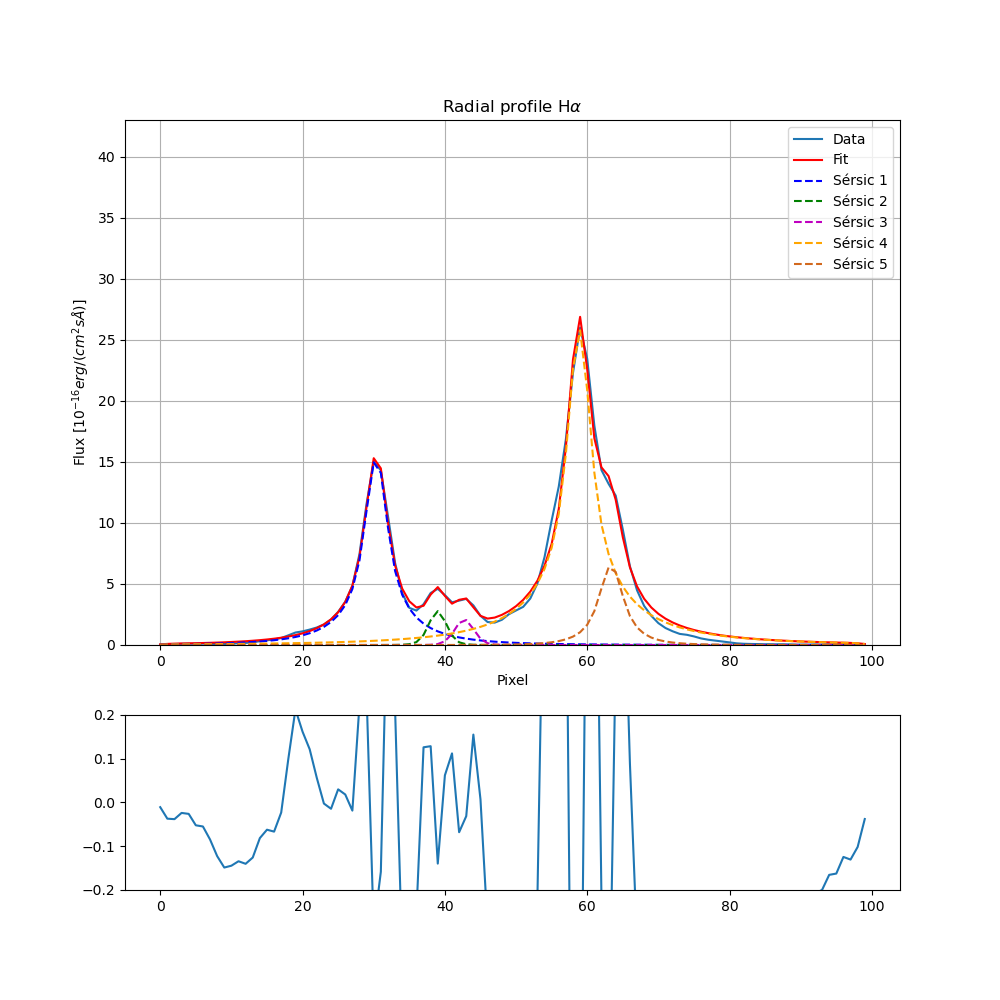

In [30]:
save_params_diff(best_params, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha_diff", output_prefix="fit")

plot_diff(x_axes, best_params, radial_profile_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_diff')

In [31]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HA, covariance_HA = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes, radial_profile_HA, p0=result.x, 
                                           sigma = real_errors_HA)#, bounds = bounds_list, maxfev= 10000)

print("Optimize parameters with curve fit:")

chi2_reduced_HA, dof_HA, chi2_HA = save_params(params_curve_HA, covariance_HA, radial_profile_HA, real_errors_HA, sigmas[0],
    x_axes, n_component, line_name="Halpha", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\anaconda3\Lib\site-packages\scipy\signal\_signaltools.py:568: RuntimeWarning: invalid value encountered in multiply
  ret = ifft(sp1 * sp2, fshape, axes=axes)


Optimize parameters with curve fit:
Sérsic 1: I_e=1.1156, r_e=9.1323, n=1.8546, x_0=30.2768
Sérsic 2: I_e=2.6313, r_e=1.3534, n=0.0805, x_0=38.8994
Sérsic 3: I_e=0.7638, r_e=2.3272, n=1.0718, x_0=42.8441
Sérsic 4: I_e=3.6877, r_e=7.1735, n=1.3262, x_0=58.9685
Sérsic 5: I_e=0.6413, r_e=3.8816, n=1.7752, x_0=64.0153
[1.07274637e-01 4.59891464e-01 1.53185293e-01 1.64937546e-02
 4.15359830e+01 1.11808518e+01 2.36127126e+00 1.95052645e-01
 6.38587654e-01 1.04965148e+00 6.79583647e-01 2.47868925e-01
 3.27533718e-01 3.84913328e-01 6.85898327e-02 1.12751832e-01
 6.47946555e-01 2.42238025e+00 8.39367491e-01 2.20492955e-01]
2.052621330706174


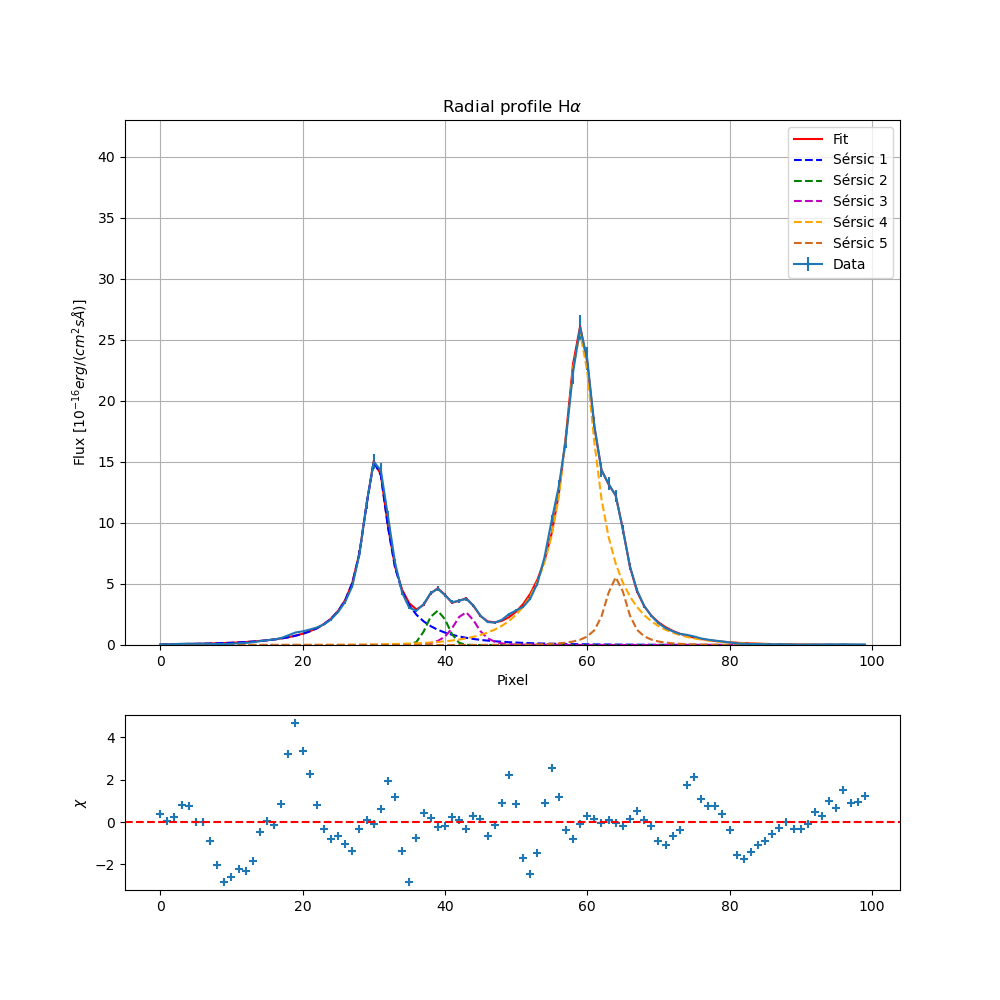

In [32]:
plot_curve(x_axes, params_curve_HA, radial_profile_HA, real_errors_HA, sigmas[0], r"Radial profile H$\alpha$")
plt.savefig('Radial_profile_Halpha_curve')

In [33]:
fit_HA = pd.read_csv("Halpha_fit.csv", index_col=0)
x_0_HA = fit_HA.iloc[3].values
bounds_HA = [
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (x_0_HA[0]-seeing[-1]/2, x_0_HA[0]+seeing[-1]/2),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[1]-seeing[-1]/2, x_0_HA[1]+seeing[-1]/2),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (x_0_HA[2]-seeing[-1]/2, x_0_HA[2]+seeing[-1]/2),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (x_0_HA[3]-seeing[-1]/2, x_0_HA[3]+seeing[-1]/2),

    (0, 20),
    (0, 5),
    (0.1, 10),
    (x_0_HA[4]-seeing[-1]/2, x_0_HA[4]+seeing[-1]/2),
]

bounds_OIII =[
    (0, 10),    # I_e: da 0 a 10 (o un valore ragionevole)
    (0, 10),  # r_e: da 0.1 a 50
    (0.1, 10),  # n: da 0.1 a 10
    (31, 33),   # x_0: circa la posizione di Halpha

    (0, 5),
    (0, 3),
    (0.1, 10),
    (40, 41),

    (0, 5),
    (0, 3),
    (0.1, 10),
    (44, 46),

    (0, 20),
    (0, 50),
    (0.1, 10),
    (60, 62),

    (0, 10),
    (0, 5),
    (0.1, 10),
    (65, 66),
]

## H$\beta$

Text(0.5, 1.0, 'H$\\beta$')

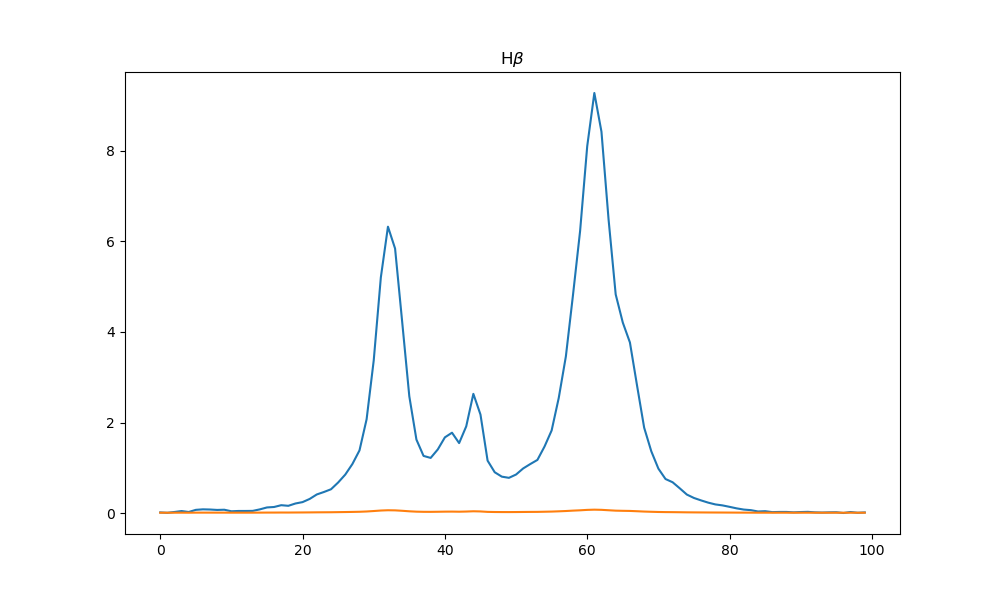

In [34]:
mask_HB = (wv > l_HB-8)*(wv < l_HB+8)
image_HB = image_cut[:, mask_HB] 
image_error_HB = image_error_cut[:, mask_HB]
radial_profile_HB = np.sum(image_HB, axis = 1)
radial_profile_error_HB = np.sqrt(np.sum(image_error_HB**2, axis = 1))
real_errors_HB = np.sqrt(radial_profile_error_HB**2+(sky_err[2])**2+(0.04*radial_profile_HB)**2)

plt.figure(figsize=(10, 6))
x_axes = np.arange(0, 100, 1)
plt.plot(x_axes, radial_profile_HB)
plt.plot(x_axes, radial_profile_error_HB)
plt.title(r'H$\beta$')

In [35]:
# Bounds:
bounds = bounds_OIII

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_HB, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 1047.8647778315
differential_evolution step 2: f(x)= 1047.8647778315
differential_evolution step 3: f(x)= 1047.8647778315
differential_evolution step 4: f(x)= 1047.8647778315
differential_evolution step 5: f(x)= 576.9745986411715
differential_evolution step 6: f(x)= 326.5850942002822
differential_evolution step 7: f(x)= 189.0778900624441
differential_evolution step 8: f(x)= 189.0778900624441
differential_evolution step 9: f(x)= 189.0778900624441
differential_evolution step 10: f(x)= 189.0778900624441
differential_evolution step 11: f(x)= 88.3891550213165
differential_evolution step 12: f(x)= 55.186841635798906
differential_evolution step 13: f(x)= 24.1630885934739
differential_evolution step 14: f(x)= 24.1630885934739
differential_evolution step 15: f(x)= 24.1630885934739
differential_evolution step 16: f(x)= 24.1630885934739
differential_evolution step 17: f(x)= 24.1630885934739
differential_evolution step 18: f(x)= 24.1630885934739
differential_ev

Sérsic 1: I_e=0.4285, r_e=8.9766, n=2.0052, x_0=32.2062
Sérsic 2: I_e=4.2905, r_e=0.2598, n=0.1292, x_0=40.3810
Sérsic 3: I_e=0.7640, r_e=1.2714, n=1.2640, x_0=44.1385
Sérsic 4: I_e=1.2801, r_e=7.7217, n=1.3663, x_0=61.0345
Sérsic 5: I_e=0.0168, r_e=1.6872, n=5.0862, x_0=65.9752


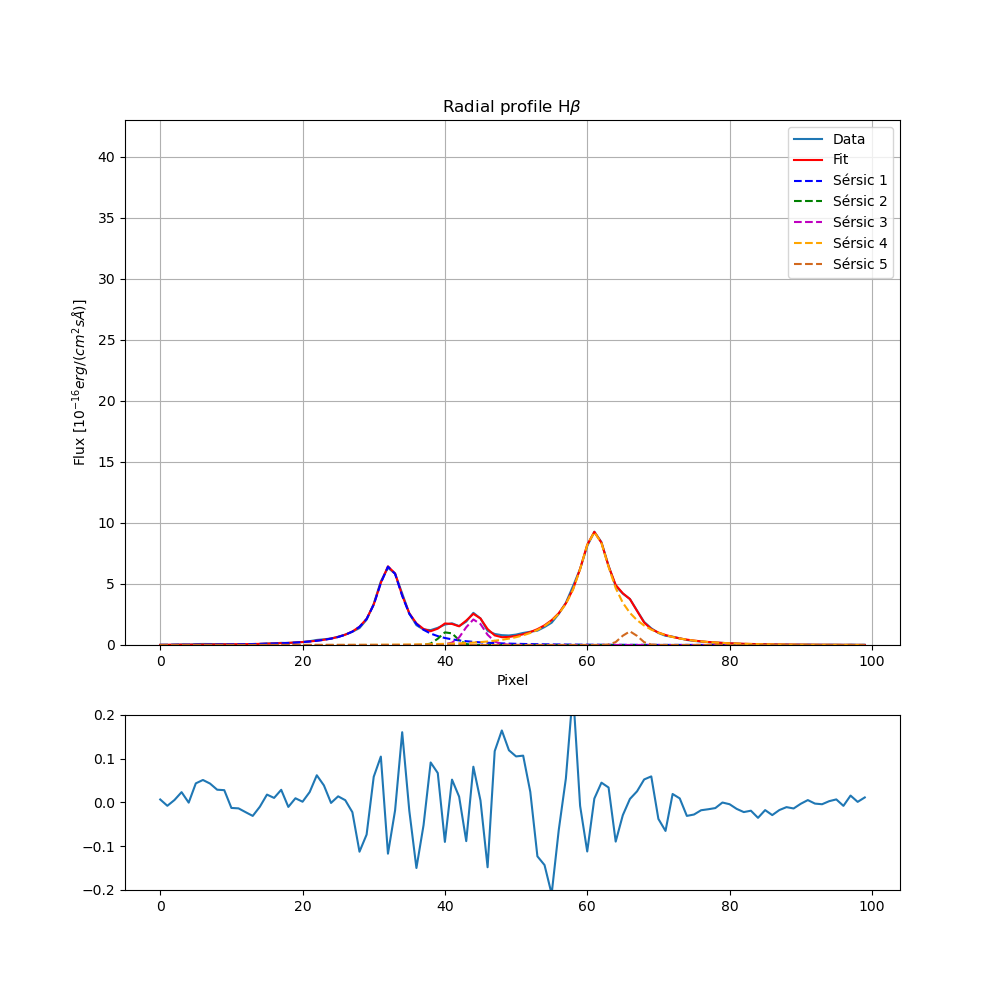

In [36]:
save_params_diff(best_params, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="HBeta", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_diff')

In [37]:
#bounds = bounds
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_HB, covariance_HB = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), 
                                           x_axes, radial_profile_HB, p0=result.x, sigma = real_errors_HB, maxfev = 10000)  #, bounds = bounds_list, maxfev = 10000)

print("Optimize parameters with curve fit:")
chi2_reduced_HB, dof_HB, chi2_HB = save_params(params_curve_HB, covariance_HB, radial_profile_HB, real_errors_HB, sigmas[1],
    x_axes, n_component, line_name="Hbeta", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.3165, r_e=10.7564, n=2.2612, x_0=32.1932
Sérsic 2: I_e=2.8447, r_e=0.3084, n=0.1901, x_0=40.2887
Sérsic 3: I_e=0.1600, r_e=3.8401, n=2.3372, x_0=44.0660
Sérsic 4: I_e=1.2591, r_e=7.5044, n=1.3874, x_0=60.9952
Sérsic 5: I_e=0.0249, r_e=6.0368, n=3.9068, x_0=65.9751
[3.46210010e-02 7.64921033e-01 9.78267788e-02 3.51505716e-02
 3.97703305e+02 4.55667752e+01 2.26569381e+02 1.16460229e-01
 4.27465382e-01 6.32099265e+00 4.18072605e+00 7.63488235e-02
 1.75333023e-01 8.99540617e-01 1.06445891e-01 5.87347222e-02
 4.11911327e-01 6.28702800e+01 2.43799991e+01 4.39040395e-02]
0.7376875151663802


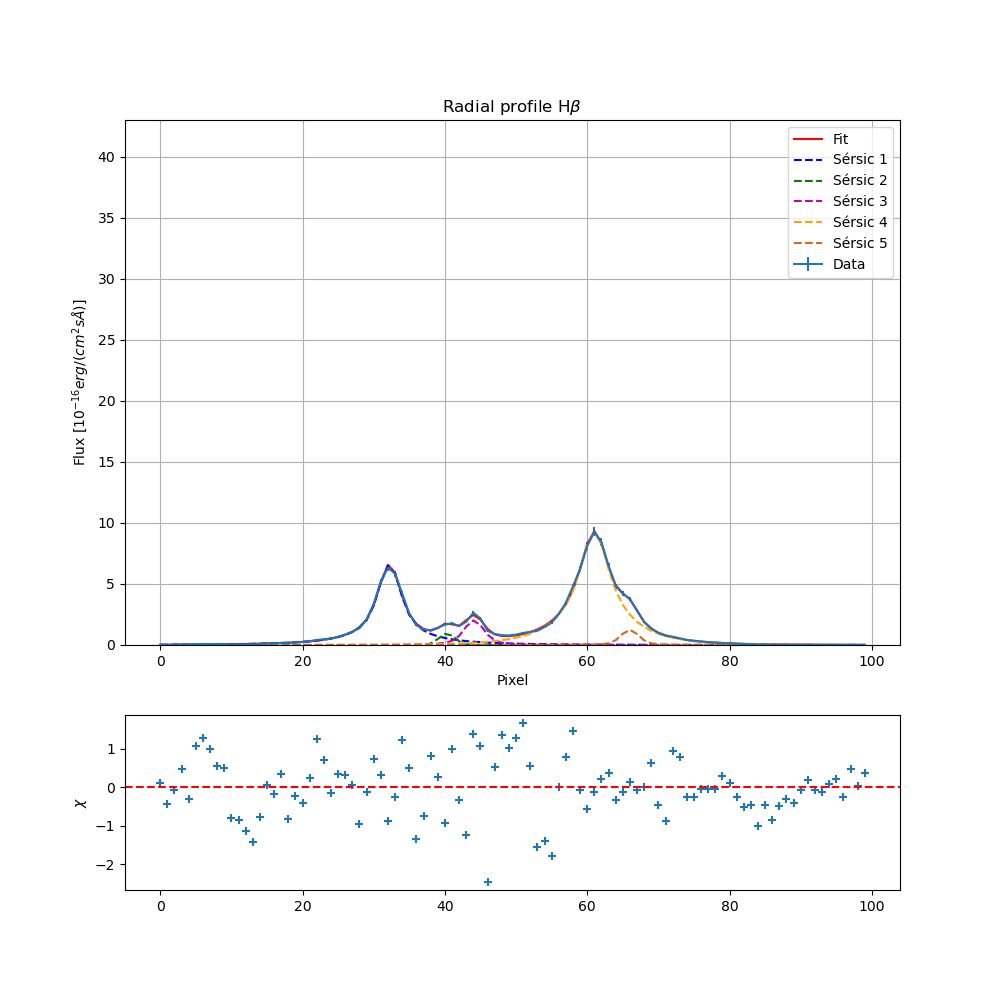

In [38]:
# Plots:
plot_curve(x_axes, params_curve_HB, radial_profile_HB, real_errors_HB, sigmas[1], r"Radial profile H$\beta$")
plt.savefig('Radial_profile_Hbeta_curve')

## [NII]

Text(0.5, 1.0, '[NII]')

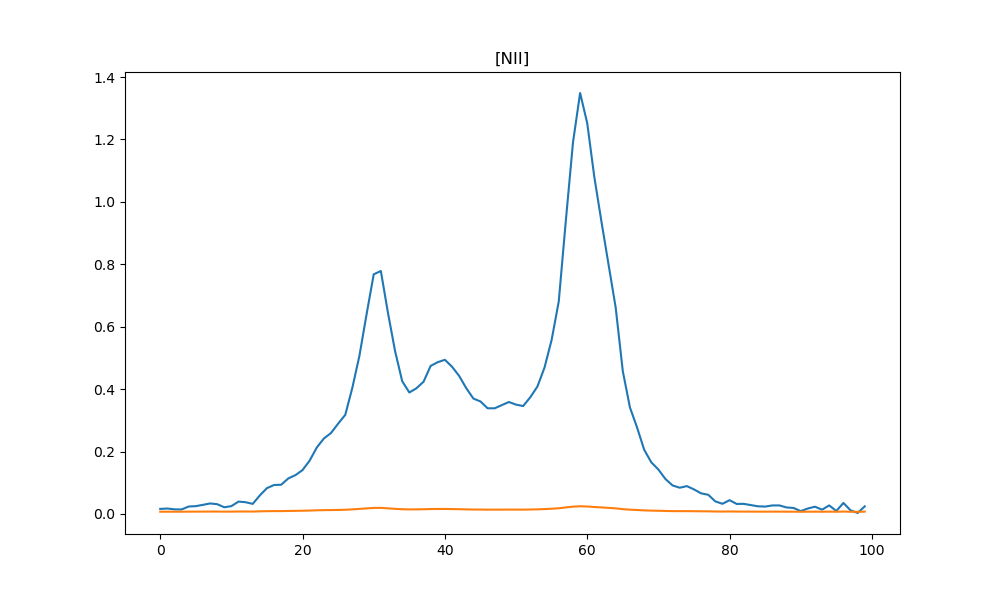

In [39]:
mask_NII = (wv > l_NII-8)*(wv < l_NII+8)
image_NII = image_cut[:, mask_NII]
image_error_NII = image_error_cut[:, mask_NII]
radial_profile_NII = np.sum(image_NII, axis = 1)
radial_profile_error_NII = np.sqrt(np.sum(image_error_NII**2, axis = 1))
real_errors_NII = np.sqrt(radial_profile_error_NII**2+(sky_err[2])**2+(0.04*radial_profile_NII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_NII)
plt.plot(x_axes, radial_profile_error_NII)
plt.title(r'[NII]')

In [40]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_NII, sigmas[2])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 7260.233067294914
differential_evolution step 2: f(x)= 1196.1708986105175
differential_evolution step 3: f(x)= 248.7059870127717
differential_evolution step 4: f(x)= 248.7059870127717
differential_evolution step 5: f(x)= 248.7059870127717
differential_evolution step 6: f(x)= 248.7059870127717
differential_evolution step 7: f(x)= 248.7059870127717
differential_evolution step 8: f(x)= 248.7059870127717
differential_evolution step 9: f(x)= 248.7059870127717
differential_evolution step 10: f(x)= 248.7059870127717
differential_evolution step 11: f(x)= 182.17745854050779
differential_evolution step 12: f(x)= 182.17745854050779
differential_evolution step 13: f(x)= 182.17745854050779
differential_evolution step 14: f(x)= 182.17745854050779
differential_evolution step 15: f(x)= 182.17745854050779
differential_evolution step 16: f(x)= 182.17745854050779
differential_evolution step 17: f(x)= 182.17745854050779
differential_evolution step 18: f(x)= 182.1774585

Sérsic 1: I_e=0.1246, r_e=10.0000, n=1.1591, x_0=30.4709
Sérsic 2: I_e=0.1919, r_e=1.8532, n=0.2219, x_0=38.9922
Sérsic 3: I_e=0.1590, r_e=3.0000, n=0.2944, x_0=44.0346
Sérsic 4: I_e=0.1261, r_e=12.9290, n=1.5413, x_0=58.9940
Sérsic 5: I_e=0.2297, r_e=1.5003, n=0.1234, x_0=62.8248


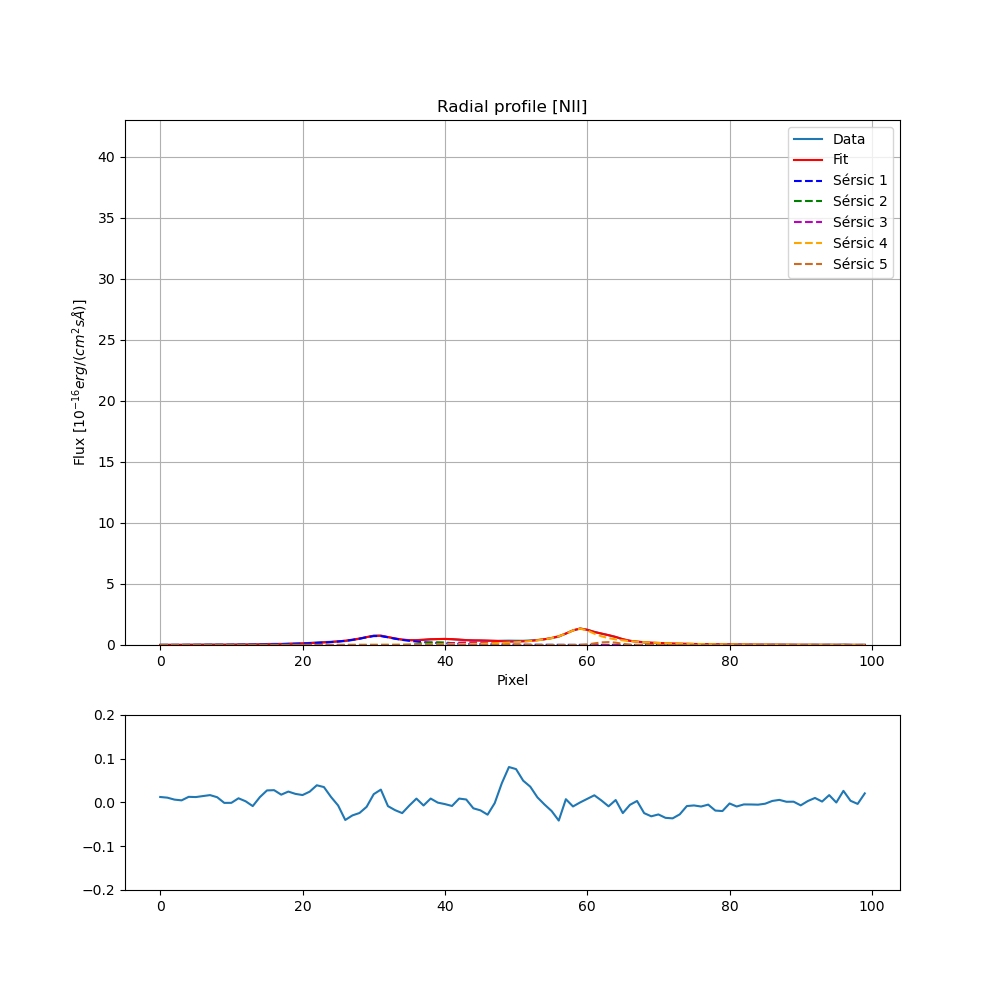

In [41]:
save_params_diff(best_params, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_diff')

In [42]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_NII, covariance_NII = curve_fit(lambda x, *params: model_convolved(x, sigmas[2], *params), x_axes, radial_profile_NII, 
                                             p0=result.x, sigma = real_errors_NII)#, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_NII, dof_NII, chi2_NII = save_params(params_curve_NII, covariance_NII, radial_profile_NII, real_errors_NII, sigmas[2],
    x_axes, n_component, line_name="NII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.0758, r_e=14.7968, n=1.4810, x_0=30.4749
Sérsic 2: I_e=0.1615, r_e=2.4162, n=0.3276, x_0=39.6532
Sérsic 3: I_e=0.0879, r_e=5.0286, n=0.4872, x_0=45.9755
Sérsic 4: I_e=0.0983, r_e=13.2555, n=1.6645, x_0=58.7743
Sérsic 5: I_e=0.1735, r_e=2.4665, n=0.5993, x_0=62.2694
[0.00743941 1.00375509 0.07505322 0.0502567  0.0542875  0.55325007
 0.15831442 0.6937525  0.05589712 1.39831599 0.33851048 2.84083094
 0.01665481 1.22977043 0.1012467  0.10599526 0.04082319 0.36886145
 0.1577251  0.29985639]
0.11906682953935296


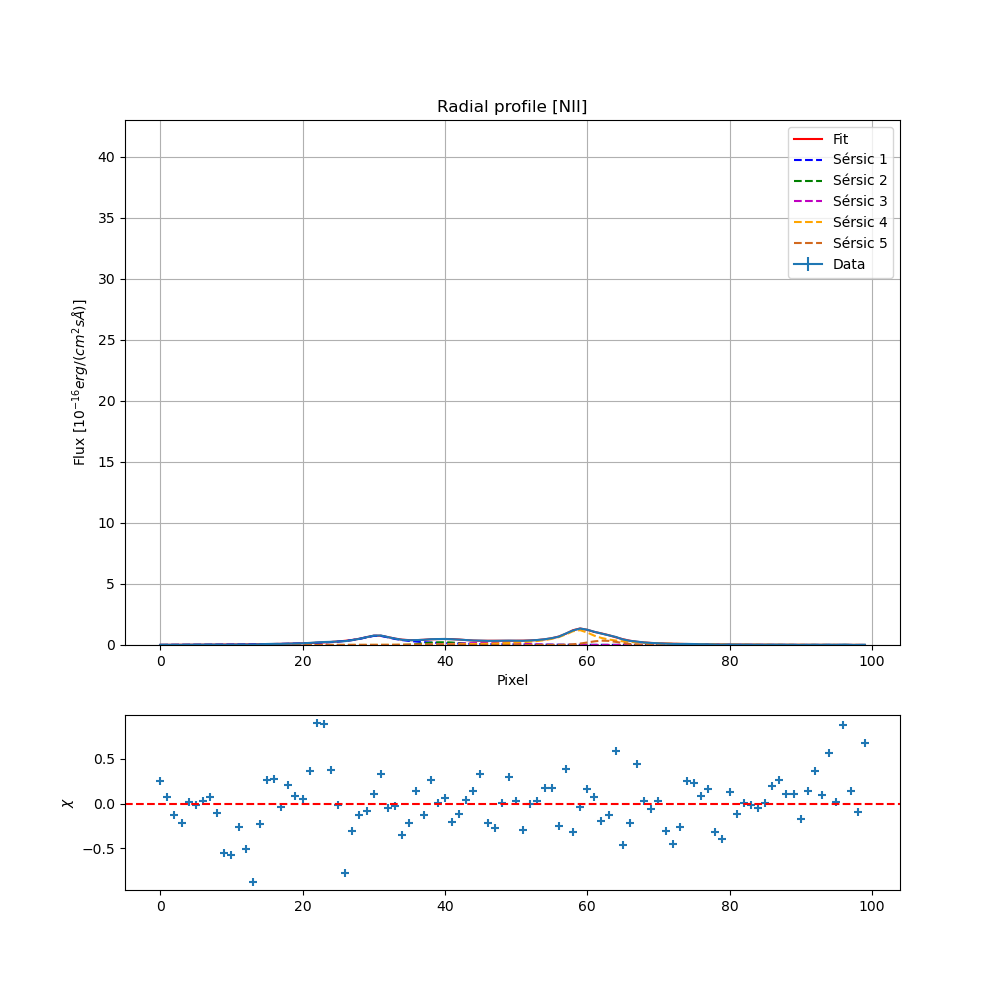

In [43]:
plot_curve(x_axes, params_curve_NII, radial_profile_NII, real_errors_NII, sigmas[2], r"Radial profile [NII]")
plt.savefig('Radial_profile_NII_curve')

## [SII]

Text(0.5, 1.0, '[SII]')

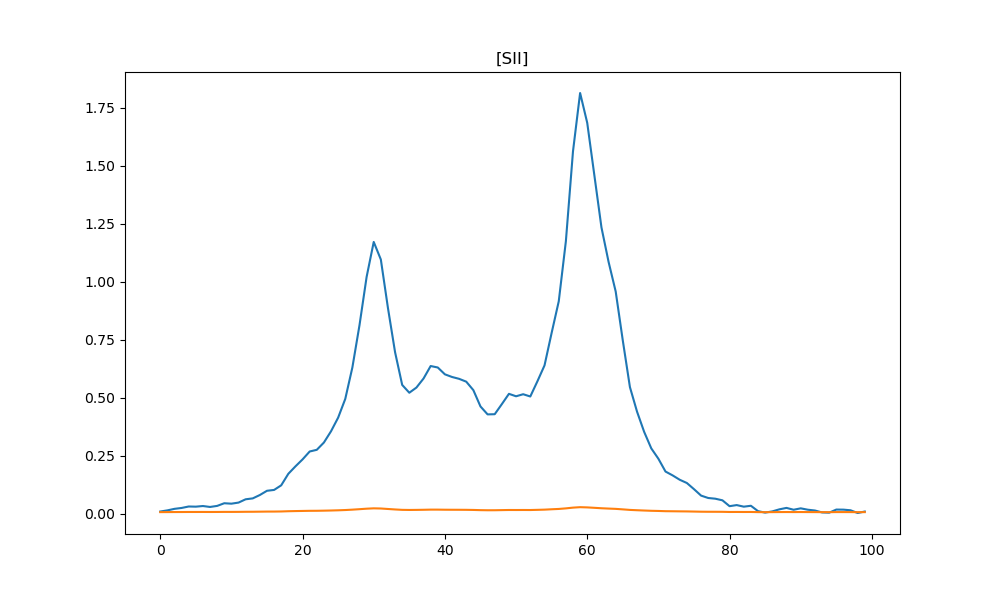

In [44]:
mask_SII = (wv > l_SII-8)*(wv < l_SII+8)
image_SII = image_cut[:, mask_SII] 
image_error_SII = image_error_cut[:, mask_SII]
radial_profile_SII = np.sum(image_SII, axis = 1)
radial_profile_error_SII = np.sqrt(np.sum(image_error_SII**2, axis = 1))
real_errors_SII = np.sqrt(radial_profile_error_SII**2+(sky_err[2])**2+(0.04*radial_profile_SII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_SII)
plt.plot(x_axes, radial_profile_error_SII)
plt.title(r'[SII]')

In [45]:
# Bounds:
bounds = bounds_HA
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_SII, sigmas[3])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 6438.0268899688435
differential_evolution step 2: f(x)= 6438.0268899688435
differential_evolution step 3: f(x)= 6438.0268899688435
differential_evolution step 4: f(x)= 2599.9315598095823
differential_evolution step 5: f(x)= 2599.9315598095823
differential_evolution step 6: f(x)= 1421.8378118441558
differential_evolution step 7: f(x)= 418.42587238963097
differential_evolution step 8: f(x)= 344.57667320320536
differential_evolution step 9: f(x)= 96.10057272172372
differential_evolution step 10: f(x)= 96.10057272172372
differential_evolution step 11: f(x)= 96.10057272172372
differential_evolution step 12: f(x)= 96.10057272172372
differential_evolution step 13: f(x)= 49.71519044407664
differential_evolution step 14: f(x)= 49.71519044407664
differential_evolution step 15: f(x)= 49.71519044407664
differential_evolution step 16: f(x)= 49.71519044407664
differential_evolution step 17: f(x)= 49.71519044407664
differential_evolution step 18: f(x)= 49.71519044

Sérsic 1: I_e=0.1682, r_e=10.0000, n=1.2365, x_0=30.1181
Sérsic 2: I_e=0.2202, r_e=2.0235, n=0.3013, x_0=38.8575
Sérsic 3: I_e=0.1823, r_e=3.0000, n=0.4028, x_0=44.0346
Sérsic 4: I_e=0.1979, r_e=12.4029, n=1.4141, x_0=59.1673
Sérsic 5: I_e=0.1543, r_e=1.7420, n=0.5182, x_0=63.3295


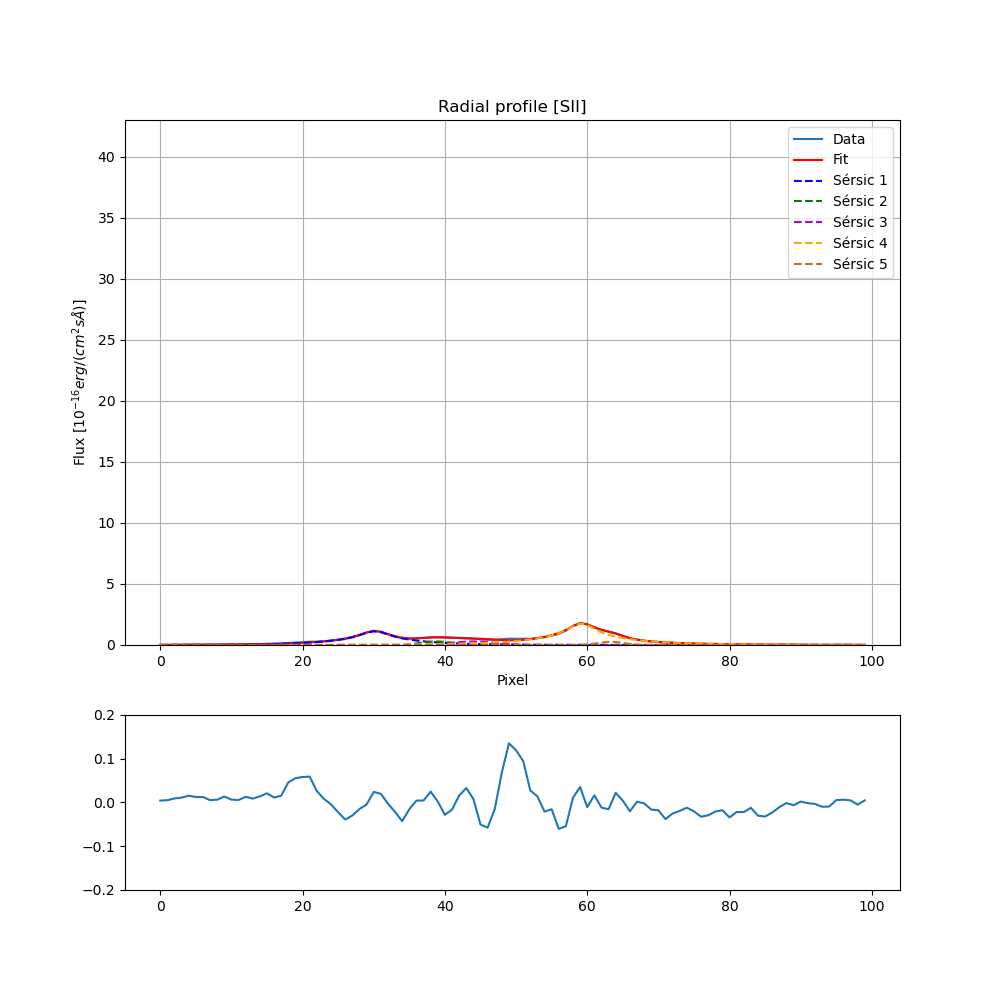

In [46]:
save_params_diff(best_params, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_diff')

In [47]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_SII, covariance_SII = curve_fit(lambda x, *params: model_convolved(x, sigmas[3], *params), x_axes, 
                                             radial_profile_SII, p0=result.x, sigma = real_errors_SII, bounds = bounds_list)

print("Optimize parameters with curve fit:")
chi2_reduced_SII, dof_SII, chi2_SII = save_params(params_curve_SII, covariance_SII, radial_profile_SII, real_errors_SII, sigmas[3],
    x_axes, n_component, line_name="SII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=0.1760, r_e=10.0000, n=1.1919, x_0=30.1089
Sérsic 2: I_e=0.2232, r_e=2.0313, n=0.2763, x_0=38.9443
Sérsic 3: I_e=0.1770, r_e=3.0000, n=0.4086, x_0=44.0346
Sérsic 4: I_e=0.2210, r_e=11.4863, n=1.2950, x_0=58.9940
Sérsic 5: I_e=0.2048, r_e=2.2081, n=0.3357, x_0=62.8248
[0.02204894 0.86094106 0.0897778  0.10400888 0.12629352 0.57171903
 0.34100477 1.24959231 0.08882824 1.18067311 0.27945426 1.95222551
 0.03904432 1.29159751 0.09274201 0.38697083 0.10078933 1.25507476
 0.31862898 1.41614913]
0.7985118761602539


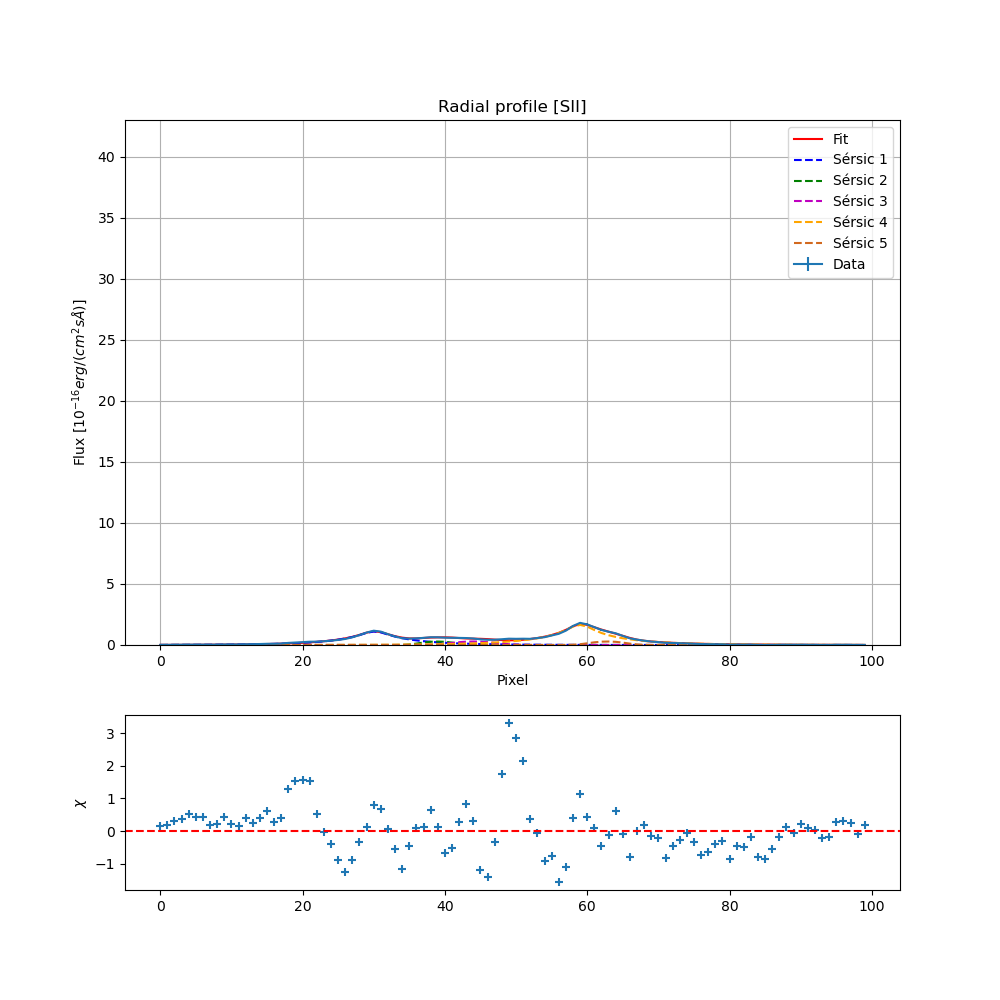

In [48]:
# Plots:
plot_curve(x_axes, params_curve_SII, radial_profile_SII, real_errors_SII, sigmas[3], r"Radial profile [SII]")
plt.savefig('Radial_profile_SII_curve')

## [OIII]

Text(0.5, 1.0, '[OIII]')

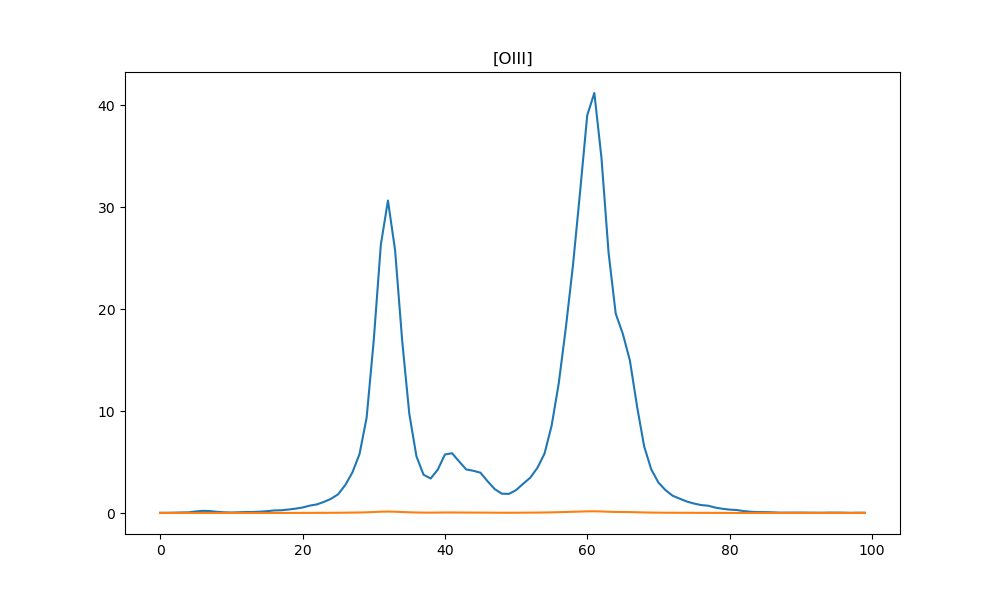

In [10]:
mask_OIII = (wv > l_OIII-8)*(wv < l_OIII+8)
image_OIII = image_cut[:, mask_OIII] 
image_error_OIII = image_error_cut[:, mask_OIII]
radial_profile_OIII = np.sum(image_OIII, axis = 1)
radial_profile_error_OIII = np.sqrt(np.sum(image_error_OIII**2, axis = 1))
real_errors_OIII = np.sqrt(radial_profile_error_OIII**2+(sky_err[2])**2+(0.04*radial_profile_OIII)**2)

plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_OIII)
plt.plot(x_axes, radial_profile_error_OIII)
plt.title(r'[OIII]')

In [50]:
# Bounds:
bounds = bounds_OIII
# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_OIII, sigmas[4])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 2632.763549580403
differential_evolution step 2: f(x)= 2186.011618735774
differential_evolution step 3: f(x)= 1506.9401871248017
differential_evolution step 4: f(x)= 1506.9401871248017
differential_evolution step 5: f(x)= 1506.9401871248017
differential_evolution step 6: f(x)= 1506.9401871248017
differential_evolution step 7: f(x)= 1506.9401871248017
differential_evolution step 8: f(x)= 1279.761205724247
differential_evolution step 9: f(x)= 1279.761205724247
differential_evolution step 10: f(x)= 1279.761205724247
differential_evolution step 11: f(x)= 972.429483697384
differential_evolution step 12: f(x)= 972.429483697384
differential_evolution step 13: f(x)= 972.429483697384
differential_evolution step 14: f(x)= 440.05675905557854
differential_evolution step 15: f(x)= 440.05675905557854
differential_evolution step 16: f(x)= 440.05675905557854
differential_evolution step 17: f(x)= 440.05675905557854
differential_evolution step 18: f(x)= 440.056759055

Sérsic 1: I_e=4.2359, r_e=4.4714, n=1.5700, x_0=31.9737
Sérsic 2: I_e=2.9859, r_e=0.9918, n=0.6871, x_0=40.5590
Sérsic 3: I_e=1.7910, r_e=2.0364, n=0.5765, x_0=44.3710
Sérsic 4: I_e=9.0122, r_e=5.4800, n=1.0724, x_0=60.6276
Sérsic 5: I_e=1.8618, r_e=0.4211, n=2.5161, x_0=65.9257


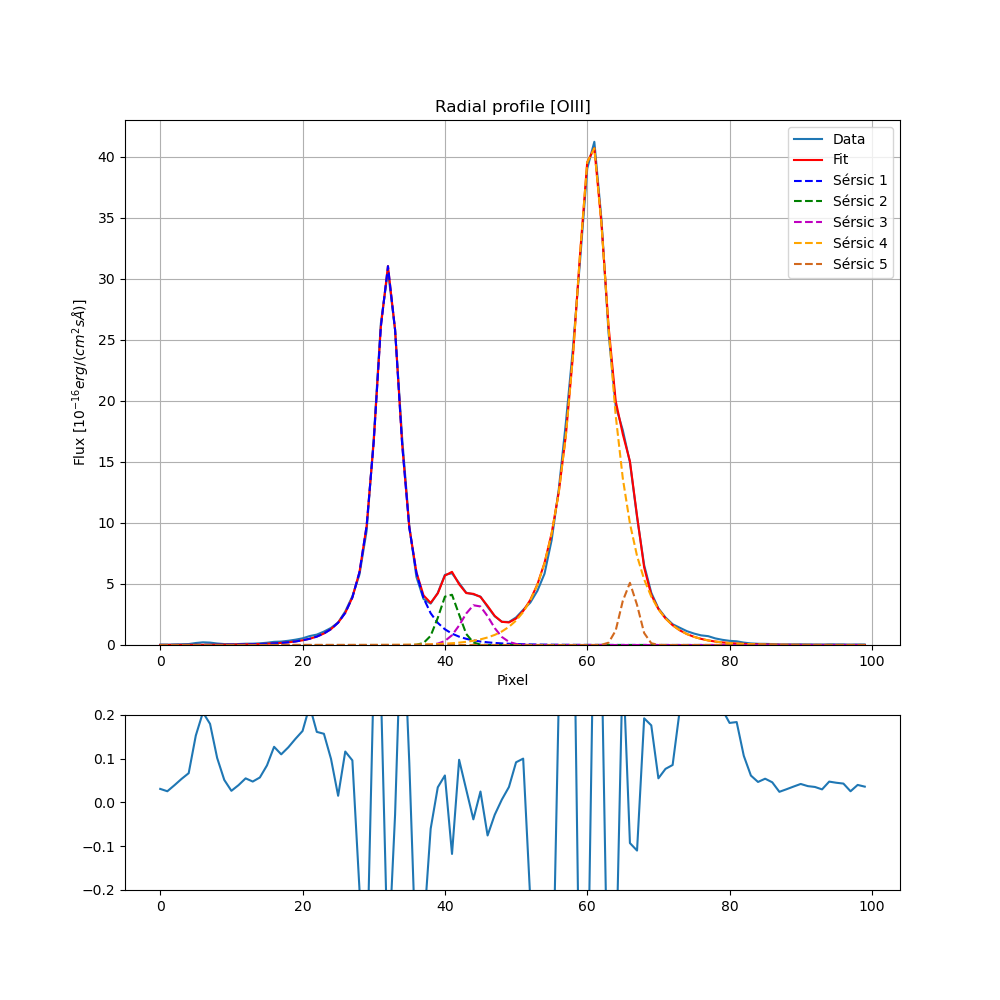

In [51]:
save_params_diff(best_params, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_diff')

In [53]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_OIII, covariance_OIII = curve_fit(lambda x, *params: model_convolved(x, sigmas[4], *params), x_axes, radial_profile_OIII, 
                                               p0=result.x, sigma = real_errors_OIII, bounds = bounds_list, maxfev=10000)

print("Optimize parameters with curve fit:")
chi2_reduced_OIII, dof_OIII, chi2_OIII = save_params(params_curve_OIII, covariance_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4],
    x_axes, n_component, line_name="OIII", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.6152, r_e=5.7829, n=2.0182, x_0=31.9710
Sérsic 2: I_e=5.0000, r_e=0.6539, n=0.3872, x_0=40.4202
Sérsic 3: I_e=2.7689, r_e=1.7894, n=0.1758, x_0=44.0001
Sérsic 4: I_e=6.1659, r_e=6.3844, n=1.3991, x_0=60.5692
Sérsic 5: I_e=4.1180, r_e=1.1403, n=0.6673, x_0=65.6190
[ 0.19029791  0.2042703   0.08129032  0.04048311 32.98660713  0.72045997
  6.21165693  0.62501853  0.5945958   1.23525164  0.35469375  1.22062267
  0.34732811  0.12714321  0.0495805   0.07229269  4.22594297  0.43256735
  0.99475248  0.21810817]
1.9364508386678196


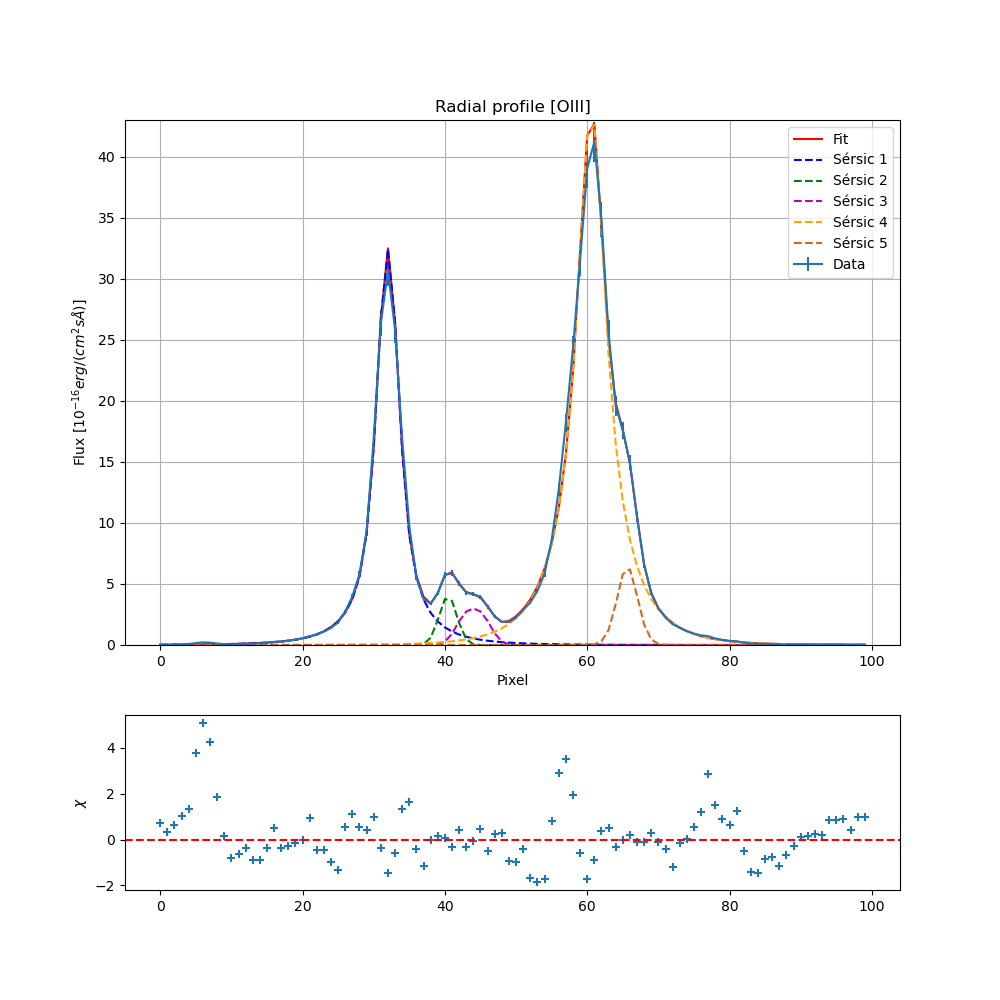

In [54]:
plot_curve(x_axes, params_curve_OIII, radial_profile_OIII, real_errors_OIII, sigmas[4], r"Radial profile [OIII]")
plt.savefig('Radial_profile_OIII_curve')

In [55]:
chi_red = [chi2_reduced_HA, chi2_reduced_HB, chi2_reduced_NII, chi2_reduced_SII, chi2_reduced_OIII]
dof = [dof_HA, dof_HB, dof_NII, dof_SII, dof_OIII]
chi = [chi2_HA, chi2_HB, chi2_NII, chi2_SII, chi2_OIII]

d1 = {'Name': ['Halpha', 'Hbeta', 'NII', 'SII', 'OIII'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit.csv", index= False)

## Continuum 1

Text(0.5, 1.0, 'Continuum 1')

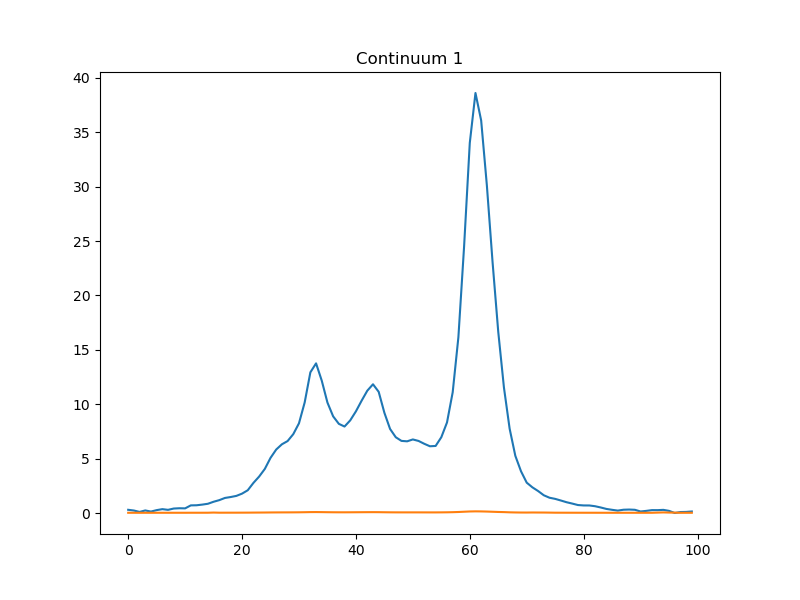

In [56]:
mask_continuum_1 = (wv > 4500)*(wv < 4800)
image_continuum_1 = image_cut[:, mask_continuum_1]
image_error_continuum_1 = image_error_cut[:, mask_continuum_1]
radial_profile_continuum_1 = np.sum(image_continuum_1, axis = 1)
radial_profile_error_continuum_1 = np.sqrt(np.sum(image_error_continuum_1**2, axis = 1))
real_errors_c1 = np.sqrt(radial_profile_error_continuum_1**2+(sky_err[2])**2+(0.04*radial_profile_continuum_1)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_1)
plt.plot(x_axes, radial_profile_error_continuum_1)
plt.title(r'Continuum 1')

In [57]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_1, sigmas[1])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3690.9908545962703
differential_evolution step 2: f(x)= 3050.220389991589
differential_evolution step 3: f(x)= 2855.430634180936
differential_evolution step 4: f(x)= 1972.8665633332828
differential_evolution step 5: f(x)= 1471.42110251332
differential_evolution step 6: f(x)= 1170.987345590995
differential_evolution step 7: f(x)= 1170.987345590995
differential_evolution step 8: f(x)= 1170.987345590995
differential_evolution step 9: f(x)= 1170.987345590995
differential_evolution step 10: f(x)= 1170.987345590995
differential_evolution step 11: f(x)= 1170.987345590995
differential_evolution step 12: f(x)= 1170.987345590995
differential_evolution step 13: f(x)= 886.3052806949128
differential_evolution step 14: f(x)= 708.4710247144553
differential_evolution step 15: f(x)= 708.4710247144553
differential_evolution step 16: f(x)= 708.4710247144553
differential_evolution step 17: f(x)= 708.4710247144553
differential_evolution step 18: f(x)= 708.4710247144553


C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: divide by zero encountered in divide
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with differential_evolution:
Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248
Chi quadro minimo: 59.04200746881127
False


In [58]:
def plot_curve(x_axes, params_curve, radial_profile, radial_profile_err, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *params_curve)
    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].errorbar(x_axes, radial_profile, radial_profile_err, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *params_curve[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].scatter(x_axes, (radial_profile - y_fit)/radial_profile_err, marker = '+')
    ax[1].axhline(0, color ='red', linestyle ='dashed')
    ax[1].set_ylabel(r'$\chi$')

def plot_diff(x_axes, best_params, radial_profile, sigma, title = ""):
    y_fit = model_convolved(x_axes, sigma, *best_params)

    fig, ax = plt.subplots(2, 1, figsize=(10, 10), height_ratios=[3, 1])

    ax[0].plot(x_axes, radial_profile, label='Data')
    ax[0].plot(x_axes, y_fit, 'r-', label='Fit')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[0:4], sigma), 'b--', label='Sérsic 1')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[4:8], sigma), 'g--', label='Sérsic 2')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[8:12], sigma), 'm--', label='Sérsic 3')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[12:16], sigma), color='orange', linestyle='--', label='Sérsic 4')
    ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[16:20], sigma), color = 'chocolate', linestyle='--', label='Sérsic 5')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[20:24], sigma), color = 'purple', linestyle='--', label='Sérsic 6')
    #ax[0].plot(x_axes, sersic_1d_convolved(x_axes, *best_params[24:28], sigma), color = 'deeppink', linestyle='--', label='Sérsic 7')

    ax[0].set_xlabel("Pixel")
    ax[0].set_ylabel(r'Flux [$10^{-16} erg/(cm^2 s \AA )$]')
    ax[0].set_title(title)
    ax[0].legend()
    ax[0].grid(True)
    #ax[0].set_ylim(0, 30)
    #ax[0].tight_layout()
    
    ax[1].plot(x_axes, radial_profile - y_fit)
    ax[1].set_ylim(-0.2, 0.2)

Sérsic 1: I_e=2.2032, r_e=10.0000, n=1.0476, x_0=31.4673
Sérsic 2: I_e=2.5269, r_e=3.0000, n=0.2138, x_0=37.7089
Sérsic 3: I_e=4.3291, r_e=3.0000, n=0.4824, x_0=44.0108
Sérsic 4: I_e=0.8158, r_e=23.6623, n=2.4449, x_0=60.1590
Sérsic 5: I_e=13.5420, r_e=1.7624, n=0.3303, x_0=62.8248


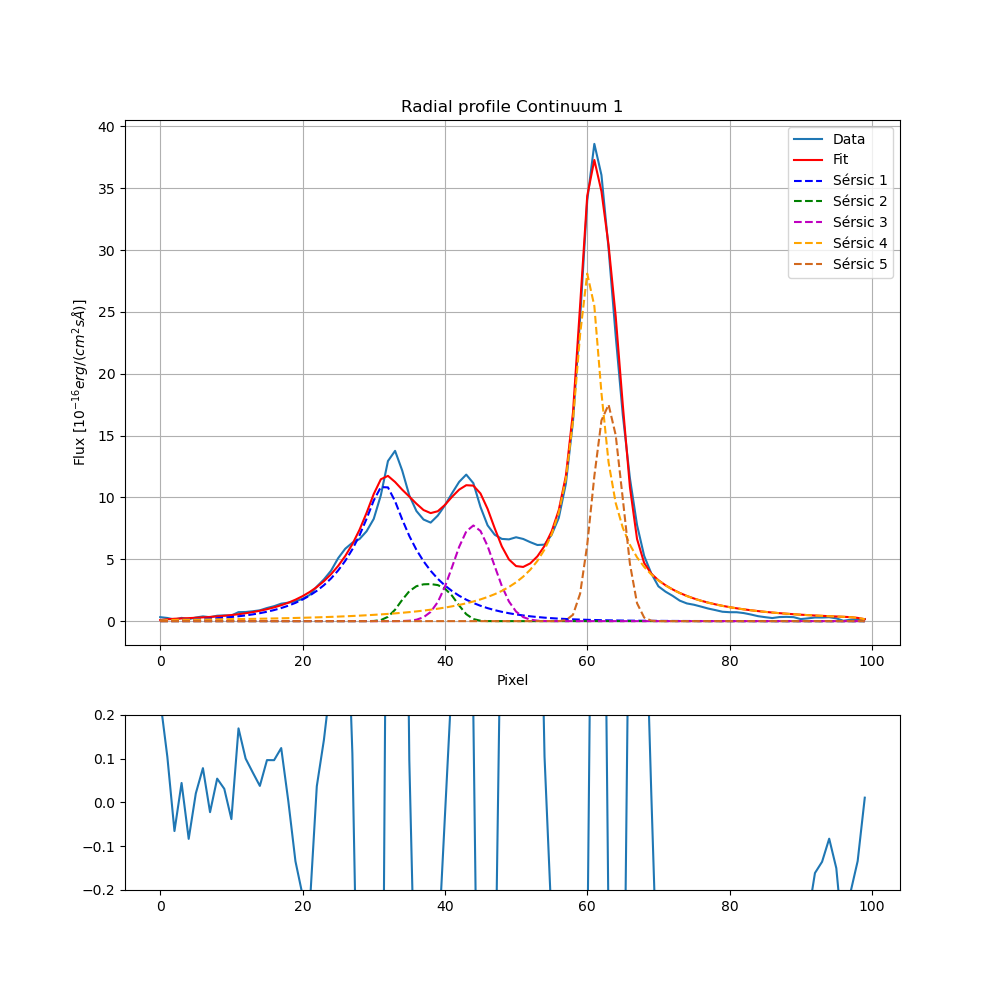

In [59]:
save_params_diff(best_params, radial_profile_continuum_1, real_errors_c1, sigmas[1],
    x_axes, n_component, line_name="Continuum_1", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_diff')

In [60]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))

params_curve_continuum_1, covariance_continuum_1 = curve_fit(lambda x, *params: model_convolved(x, sigmas[1], *params), x_axes,
                                                             radial_profile_continuum_1, p0=result.x, sigma = real_errors_c1, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_1, dof_continuum_1, chi2_continuum_1 = save_params(params_curve_continuum_1, covariance_continuum_1, 
                                                                          radial_profile_continuum_1, real_errors_c1, sigmas[1],
                                                                          x_axes, n_component, line_name="Continuum_1", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=2.4799, r_e=10.0000, n=0.9401, x_0=31.4673
Sérsic 2: I_e=2.3206, r_e=3.0000, n=0.2084, x_0=37.7089
Sérsic 3: I_e=4.5607, r_e=3.0000, n=0.4498, x_0=44.0346
Sérsic 4: I_e=1.8863, r_e=12.8447, n=1.6745, x_0=59.8852
Sérsic 5: I_e=11.0830, r_e=2.1090, n=0.4926, x_0=62.8249
[0.89755946 0.52617855 0.11500632 2.0564234  2.34832526 2.56416688
 0.79372698 3.31359809 1.82471465 0.61408124 0.26340064 0.95916304
 0.36186728 1.24892979 0.26328209 0.16833684 4.6239057  0.58162602
 0.32583222 0.88651593]
7.77173833449348


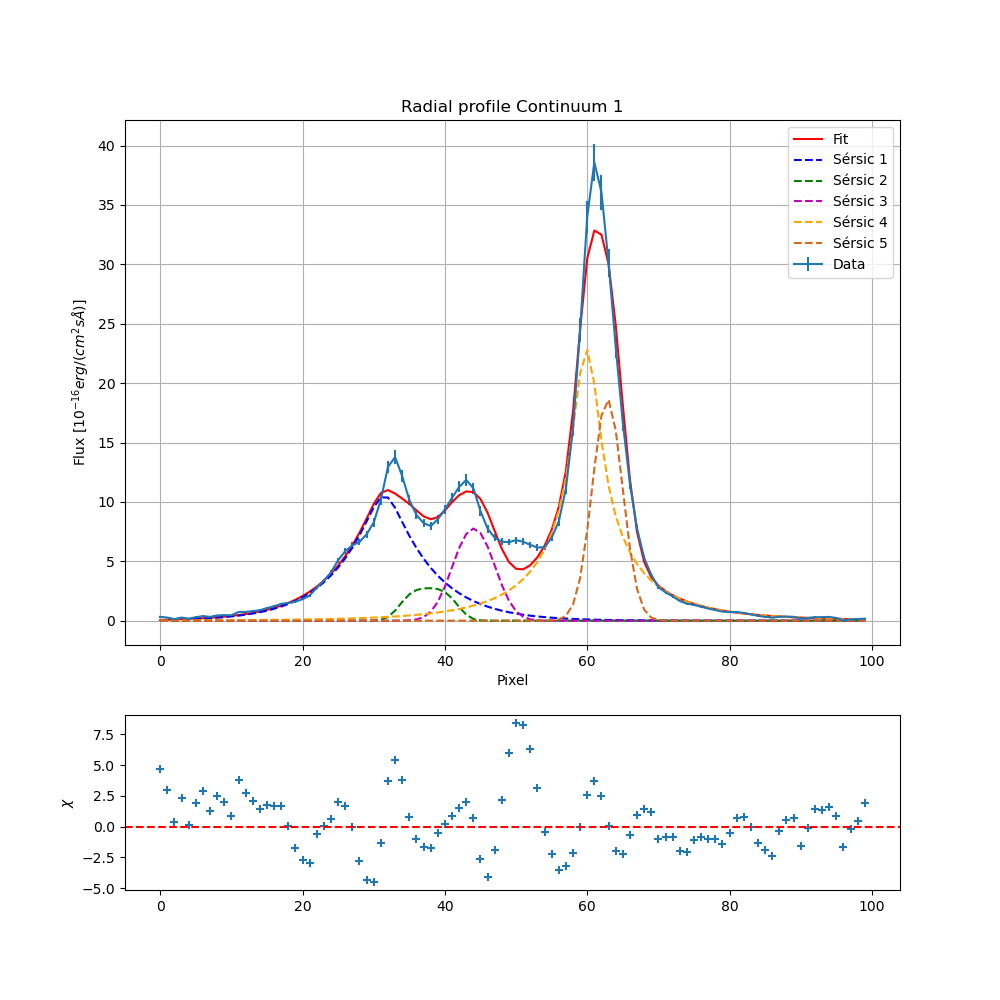

In [61]:
# Plots:
plot_curve(x_axes, params_curve_continuum_1, radial_profile_continuum_1, real_errors_c1, sigmas[1], r"Radial profile Continuum 1")
plt.savefig('Radial_profile_continuum_1_curve')

## Continuum 2 

Text(0.5, 1.0, 'Continuum 2')

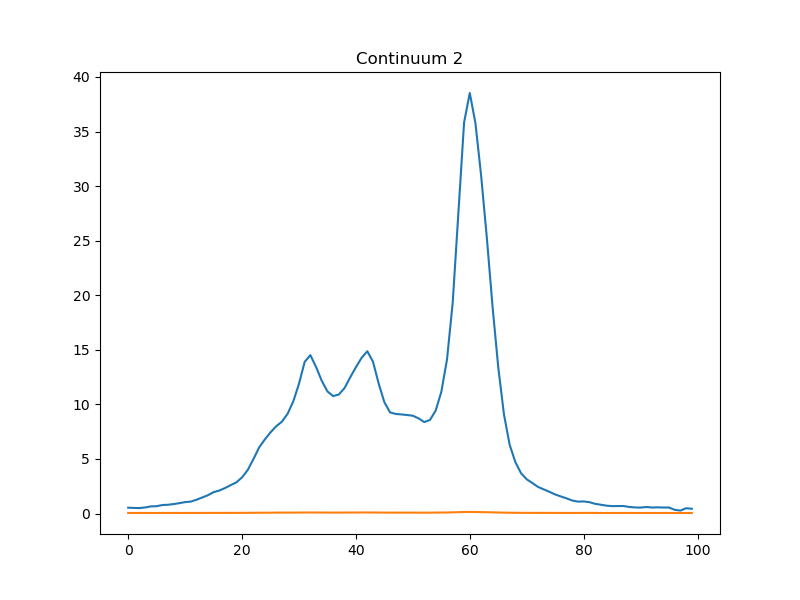

In [11]:
mask_continuum_2 = (wv > 5300)*(wv < 5800)
image_continuum_2 = image_cut[:, mask_continuum_2]
image_error_continuum_2 = image_error_cut[:, mask_continuum_2]
radial_profile_continuum_2 = np.sum(image_continuum_2, axis = 1)
radial_profile_error_continuum_2 = np.sqrt(np.sum(image_error_continuum_2**2, axis = 1))
real_errors_c2 = np.sqrt(radial_profile_error_continuum_2**2+(sky_err[2])**2+(0.04*radial_profile_continuum_2)**2)

plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_2)
plt.plot(x_axes, radial_profile_error_continuum_2)
plt.title(r'Continuum 2')

In [63]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_2, sigmas[5])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3878.713461066773
differential_evolution step 2: f(x)= 3705.938422085638
differential_evolution step 3: f(x)= 3705.938422085638
differential_evolution step 4: f(x)= 1549.8000922985884
differential_evolution step 5: f(x)= 1549.8000922985884
differential_evolution step 6: f(x)= 1272.0293353667514
differential_evolution step 7: f(x)= 1272.0293353667514
differential_evolution step 8: f(x)= 1272.0293353667514
differential_evolution step 9: f(x)= 1272.0293353667514
differential_evolution step 10: f(x)= 989.7763810805044
differential_evolution step 11: f(x)= 989.7763810805044
differential_evolution step 12: f(x)= 989.7763810805044
differential_evolution step 13: f(x)= 989.7763810805044
differential_evolution step 14: f(x)= 776.2647662096684
differential_evolution step 15: f(x)= 734.5946024868681
differential_evolution step 16: f(x)= 679.6248979418873
differential_evolution step 17: f(x)= 523.5368133945343
differential_evolution step 18: f(x)= 523.536813394

Sérsic 1: I_e=4.0375, r_e=10.0000, n=0.7687, x_0=31.4673
Sérsic 2: I_e=3.5689, r_e=2.6639, n=0.1000, x_0=40.0899
Sérsic 3: I_e=4.7279, r_e=3.0000, n=0.2986, x_0=44.0346
Sérsic 4: I_e=2.2188, r_e=15.1004, n=1.9082, x_0=59.6435
Sérsic 5: I_e=9.3060, r_e=1.5007, n=0.1000, x_0=62.8248


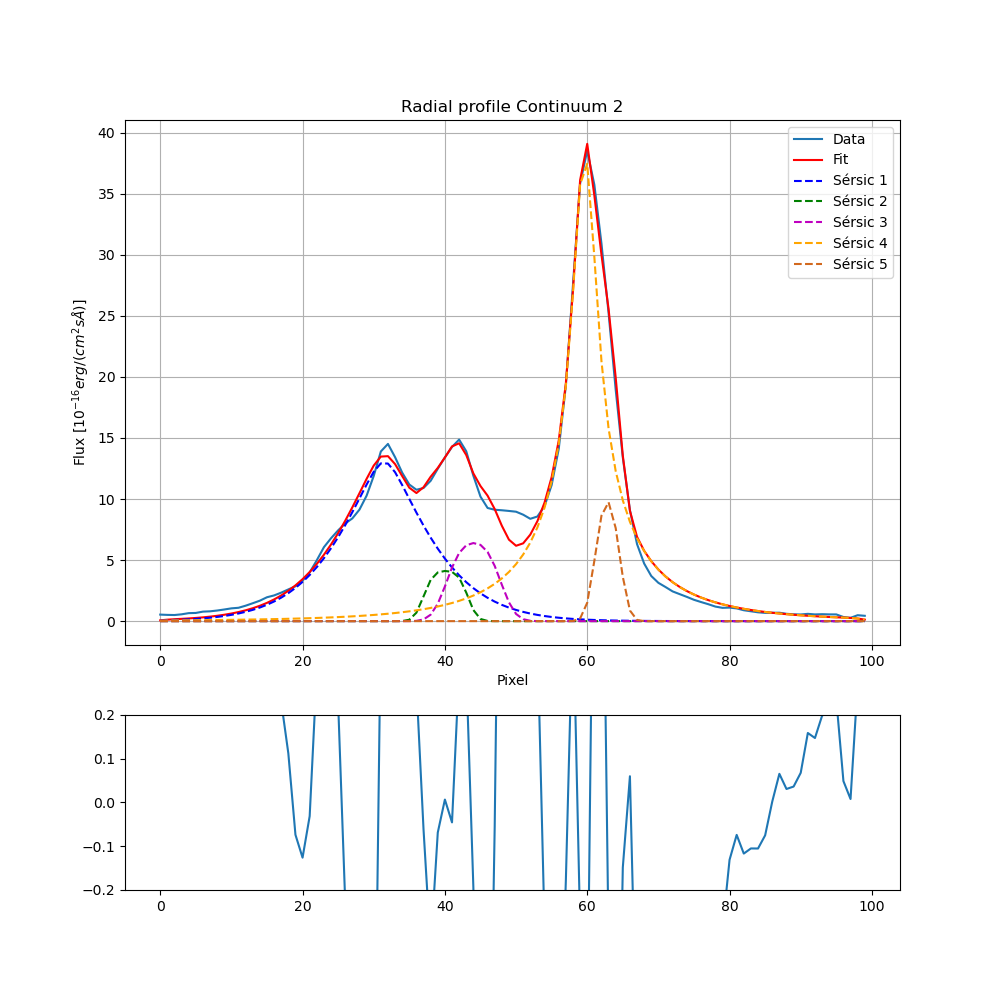

In [64]:
save_params_diff(best_params, radial_profile_continuum_2, real_errors_c2, sigmas[-1],
    x_axes, n_component, line_name="Continuum_2", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_diff')

In [65]:
lower_bounds, upper_bounds = zip(*bounds)
bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_2, covariance_continuum_2 = curve_fit(lambda x, *params: model_convolved(x, sigmas[-1], *params), x_axes, radial_profile_continuum_2, p0=result.x, 
                                                             sigma = real_errors_c2, bounds = bounds_list, maxfev=15000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_2, dof_continuum_2, chi2_continuum_2 = save_params(params_curve_continuum_2, covariance_continuum_2, radial_profile_continuum_2,
                                                                          real_errors_c2, sigmas[-1], x_axes, n_component, line_name="Continuum_2", output_prefix="fit")

Optimize parameters with curve fit:
Sérsic 1: I_e=4.0141, r_e=10.0000, n=0.7795, x_0=31.4152
Sérsic 2: I_e=3.4601, r_e=2.5201, n=0.1006, x_0=40.0401
Sérsic 3: I_e=4.7950, r_e=3.0000, n=0.3189, x_0=44.0346
Sérsic 4: I_e=0.6814, r_e=29.3918, n=2.7332, x_0=58.8324
Sérsic 5: I_e=8.8422, r_e=1.8802, n=0.5394, x_0=62.8248
[ 0.43895977  0.44184221  0.07898792  0.52224974 33.83217109 21.60695566
  2.33638807  1.32578462  3.08926692  3.11704706  0.31743668  5.0089166
  0.22316591  5.93661862  0.29940376  0.24900751  3.92827046  0.48572799
  0.38272192  0.51223754]
10.144887652627109


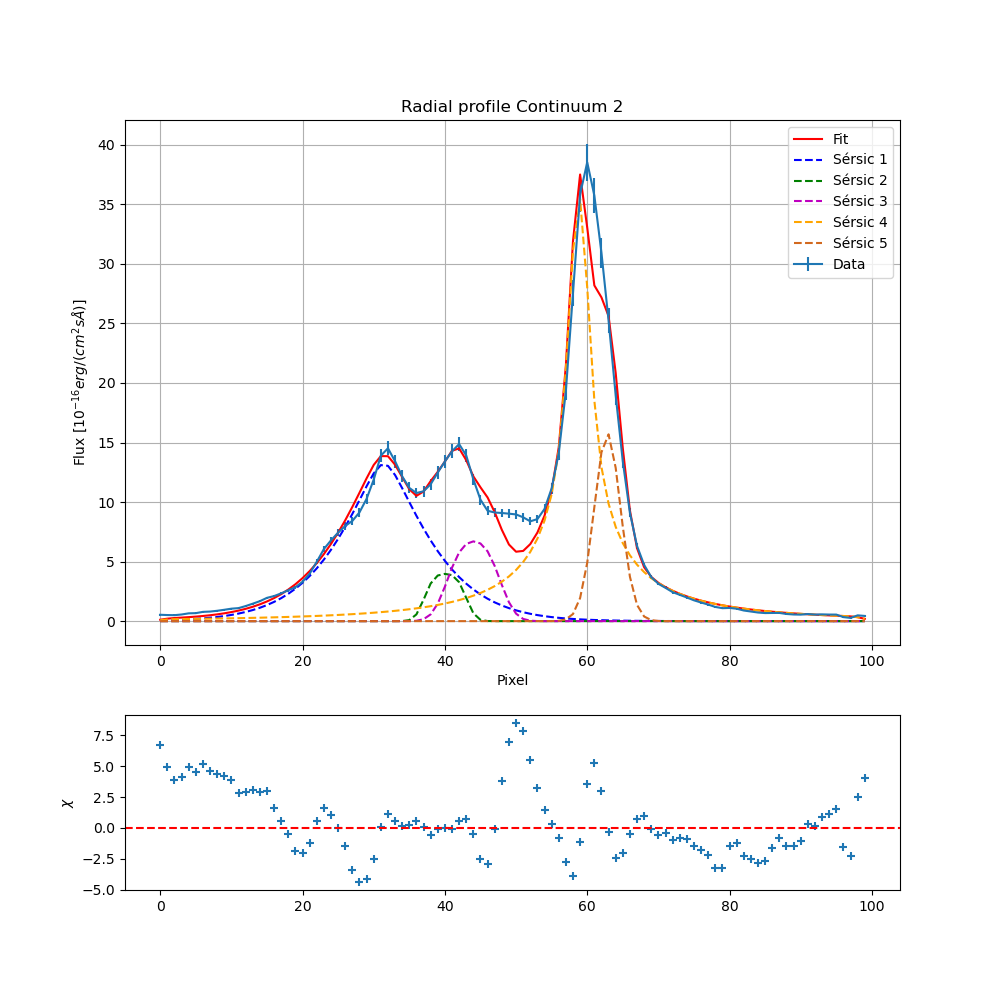

In [66]:
plot_curve(x_axes, params_curve_continuum_2, radial_profile_continuum_2, real_errors_c2, sigmas[-1], r"Radial profile Continuum 2")
plt.savefig('Radial_profile_continuum_2_curve')

##  Continuum 3

Text(0.5, 1.0, 'Continuum 3')

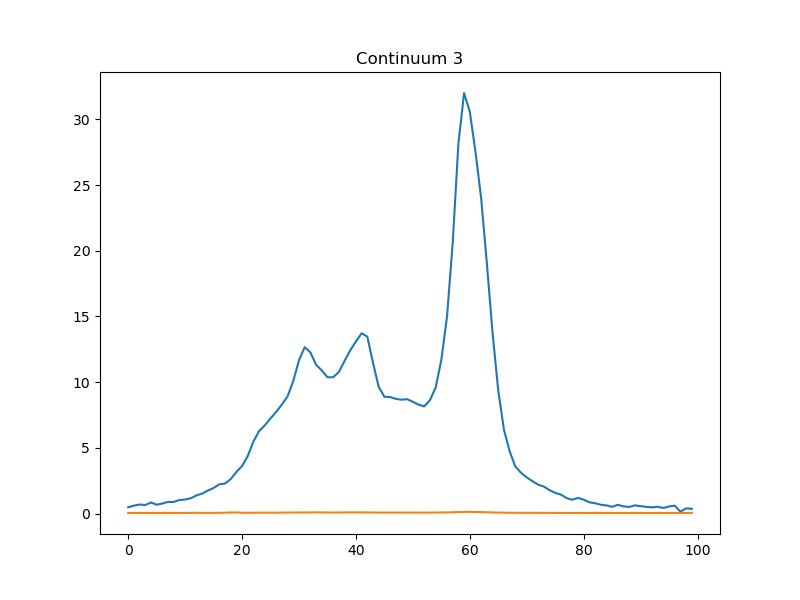

In [67]:
mask_continuum_3 =  (wv > 5950)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_continuum_3)
plt.plot(x_axes, radial_profile_error_continuum_3)
plt.title(r'Continuum 3')

In [68]:
# Bounds:
bounds = bounds_HA

# objective function for differential_evolution
def objective(params):
    return chi_squared(params, x_axes, radial_profile_continuum_3, sigmas[0])

# Global fit:
result = differential_evolution(
    objective,
    bounds,
    strategy='best1bin',
    maxiter=1000,
    popsize=20,
    tol=1e-6,
    disp=True,
    polish=True
)

best_params = result.x

print("Optimize parameters with differential_evolution:")
for i in range(n_component):
    I_e, r_e, n, x_0 = best_params[i*4:(i+1)*4]
    print(f"Sérsic {i+1}: I_e={I_e:.4f}, r_e={r_e:.4f}, n={n:.4f}, x_0={x_0:.4f}")

print("Chi quadro minimo:", result.fun)
print(result.success)

differential_evolution step 1: f(x)= 3504.2695624161074
differential_evolution step 2: f(x)= 3504.2695624161074
differential_evolution step 3: f(x)= 3365.2804376781446
differential_evolution step 4: f(x)= 2355.7801782849433
differential_evolution step 5: f(x)= 2355.7801782849433
differential_evolution step 6: f(x)= 2355.7801782849433
differential_evolution step 7: f(x)= 1425.1215678349233
differential_evolution step 8: f(x)= 1382.033351824987
differential_evolution step 9: f(x)= 1096.1349388455726
differential_evolution step 10: f(x)= 1096.1349388455726
differential_evolution step 11: f(x)= 1096.1349388455726
differential_evolution step 12: f(x)= 1096.1349388455726
differential_evolution step 13: f(x)= 1055.1622460075116
differential_evolution step 14: f(x)= 1055.1622460075116
differential_evolution step 15: f(x)= 983.6213420615425
differential_evolution step 16: f(x)= 983.6213420615425
differential_evolution step 17: f(x)= 983.6213420615425
differential_evolution step 18: f(x)= 983.62

Sérsic 1: I_e=4.3946, r_e=10.0000, n=0.6515, x_0=31.4673
Sérsic 2: I_e=3.6360, r_e=2.3424, n=0.1000, x_0=39.7787
Sérsic 3: I_e=4.1260, r_e=3.0000, n=0.2511, x_0=44.0346
Sérsic 4: I_e=2.7764, r_e=12.3794, n=1.6413, x_0=59.2010
Sérsic 5: I_e=6.7191, r_e=1.1951, n=0.1000, x_0=62.8248


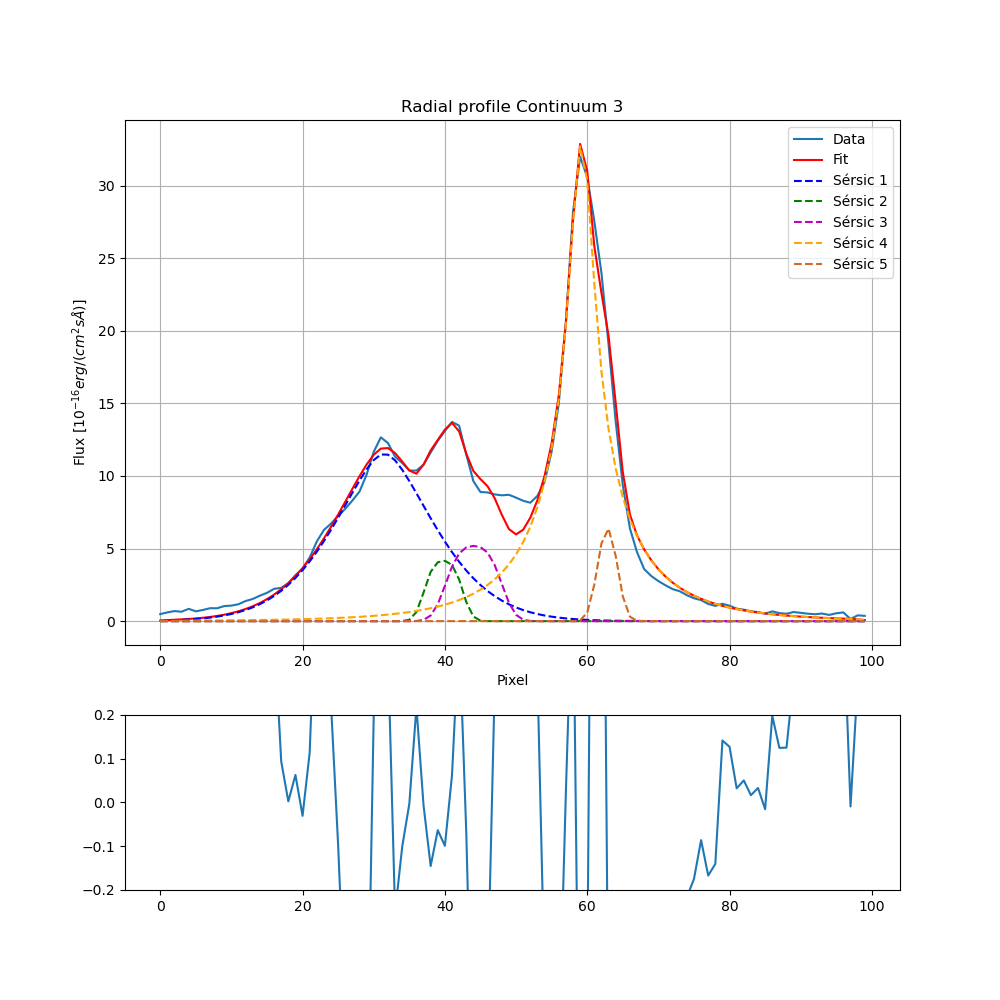

In [69]:
save_params_diff(best_params, radial_profile_continuum_3, real_errors_c3, sigmas[0],
    x_axes, n_component, line_name="Continuum_3", output_prefix="fit")
plot_diff(x_axes, best_params, radial_profile_continuum_3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_diff')

In [70]:
#lower_bounds, upper_bounds = zip(*bounds)
#bounds_list = (list(lower_bounds), list(upper_bounds))
params_curve_continuum_3, covariance_continuum_3 = curve_fit(lambda x, *params: model_convolved(x, sigmas[0], *params), x_axes,
                                                             radial_profile_continuum_3, p0=result.x, sigma = real_errors_c3) #, bounds = bounds_list, maxfev = 10000)
print("Optimize parameters with curve fit:")
chi2_reduced_continuum_3, dof_continuum_3, chi2_continuum_3 = save_params(params_curve_continuum_3, covariance_continuum_3, radial_profile_continuum_3,
                                                                          real_errors_c3, sigmas[0], x_axes, n_component, line_name="Continuum_3", output_prefix="fit")

C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: invalid value encountered in power
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:24: RuntimeWarning: Use of fft convolution on input with NAN or inf results in NAN or inf output. Consider using method='direct' instead.
  conv_profile = convolve(profile, kernel, mode='same')
C:\Users\ISAFA\AppData\Local\Temp\ipykernel_15424\637918482.py:11: RuntimeWarning: overflow encountered in exp
  return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))


Optimize parameters with curve fit:
Sérsic 1: I_e=2.3513, r_e=13.6211, n=1.0092, x_0=30.8353
Sérsic 2: I_e=3.5259, r_e=1.7140, n=0.2462, x_0=40.8516
Sérsic 3: I_e=3.4005, r_e=6.6210, n=0.2864, x_0=43.9305
Sérsic 4: I_e=0.5593, r_e=29.7407, n=2.5732, x_0=58.4353
Sérsic 5: I_e=6.7236, r_e=2.5643, n=0.6901, x_0=61.4381
[0.2715763  0.52822763 0.06143262 0.61916923 2.59563944 0.36445244
 0.66482013 0.35823689 0.57591589 1.13543951 0.13693683 1.04480445
 0.17341185 5.37067069 0.34951992 0.21721259 1.95607172 0.32595497
 0.20391428 0.48508902]
2.8570801045055787


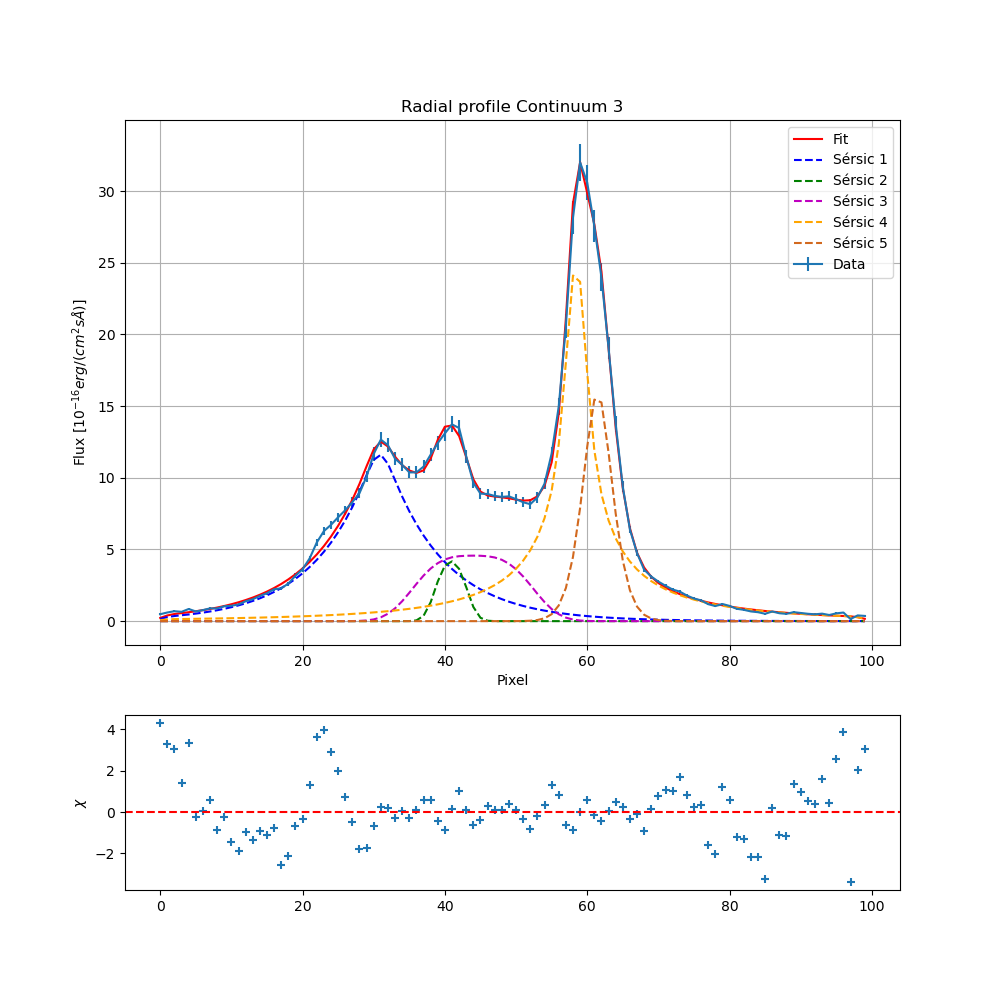

In [71]:
plot_curve(x_axes, params_curve_continuum_3, radial_profile_continuum_3, real_errors_c3, sigmas[0], r"Radial profile Continuum 3")
plt.savefig('Radial_profile_continuum_3_curve')

## Chi squared save

In [72]:
chi_red = [chi2_reduced_continuum_1, chi2_reduced_continuum_2, chi2_reduced_continuum_3]
dof = [dof_continuum_1, dof_continuum_2, dof_continuum_3]
chi = [chi2_continuum_1, chi2_continuum_2, chi2_continuum_3]

d1 = {'Name': ['Continuum 1', 'Continuum 2', 'Continuum 3'], 'Chi squared': chi,
      'Dof': dof, 'Chi reduced': chi_red}
df1 = pd.DataFrame(data=d1)
df1.to_csv("Chi_squared_curve_fit_continuum.csv", index= False)

## Halpha and continuum

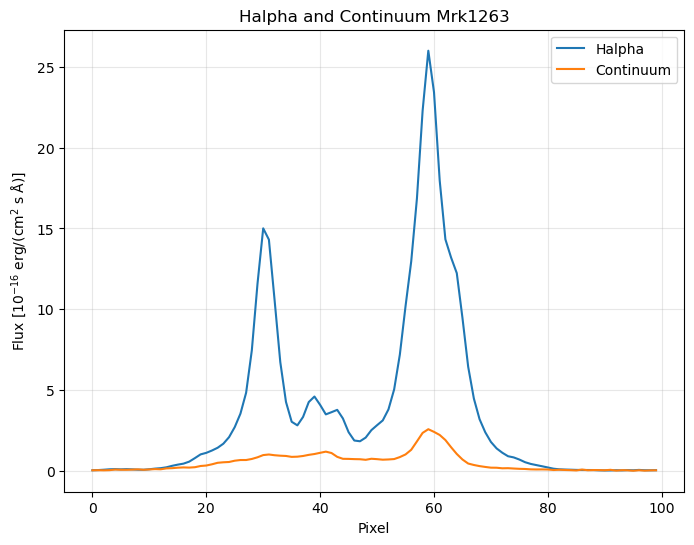

In [9]:
mask_continuum_3 = (wv > 6450)*(wv < 6500)
image_continuum_3 = image_cut[:, mask_continuum_3]
image_error_continuum_3 = image_error_cut[:, mask_continuum_3]
radial_profile_continuum_3 = np.sum(image_continuum_3, axis = 1)
radial_profile_error_continuum_3 = np.sqrt(np.sum(image_error_continuum_3**2, axis = 1))
real_errors_c3 = np.sqrt(radial_profile_error_continuum_3**2+(sky_err[2])**2+(0.04*radial_profile_continuum_3)**2)
plt.figure(figsize=(8,6))
plt.plot(x_axes, radial_profile_HA, label = 'Halpha') 
plt.plot(x_axes, radial_profile_continuum_3, label = 'Continuum')
plt.title(r'Halpha and Continuum Mrk1263')
plt.legend()
plt.xlabel('Pixel')
plt.ylabel(r'Flux [$10^{-16}$ erg/(cm$^2$ s Å)]')
plt.grid(alpha = 0.3)
plt.savefig('Halpha_continuum_Mrk1263')